In [1]:
# -*- coding: utf-8 -*-

# ============================================================
# Two-source mixed training model
#
# Source A: original 113 samples
# Source B: external/environmental 36 samples
#
# Training set:
#   89 samples from A
#   24 samples from B, balanced by treatment:
#       Control: 8
#       150% N: 8
#       50% water: 8
#   Total training samples = 113
#
# Holdout validation set for later:
#   24 samples from A
#   12 samples from B, balanced by treatment:
#       Control: 4
#       150% N: 4
#       50% water: 4
#   Total validation samples = 36
#
# This code builds the "original model" using only the mixed 113 training samples.
# ============================================================

import os
import re
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# ============================================================
# 0. Paths
# ============================================================

PROJECT_DIR = Path(r"D:\LabData\Menglin Han\Menglin Han coding\Pea project")
DATA_BASE = PROJECT_DIR / "Pea samples-new"
MODEL_DIR = DATA_BASE / "Regression model"

# Source A: original 113 patch dataset
A_PATCH_CSV_CANDIDATES = [
    MODEL_DIR / "pea_patch_dataset.csv",
    DATA_BASE / "pea_patch_dataset.csv",
]

A_PATCH_CSV = None
for p in A_PATCH_CSV_CANDIDATES:
    if p.exists():
        A_PATCH_CSV = p
        break

if A_PATCH_CSV is None:
    raise FileNotFoundError("Cannot find Source A pea_patch_dataset.csv.")

# Source B: 36-sample patch dataset
B_PATCH_CSV = MODEL_DIR / "flour_external_pea_patch_dataset.csv"

# Source B measured quality data
B_QUALITY_XLSX = MODEL_DIR / "pea validation quality.xlsx"

# Save outputs under the Pea project folder
OUT_DIR = PROJECT_DIR / "Pea_TwoSource_Mixed113_Model"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Source A patch CSV:", A_PATCH_CSV)
print("Source B patch CSV:", B_PATCH_CSV)
print("Source B quality Excel:", B_QUALITY_XLSX)
print("Output folder:", OUT_DIR)


# ============================================================
# 1. Quality indicators: use all 7 indicators
# ============================================================

QUALITY_COLS = [
    "Protein content",
    "Moisture content",
    "Water uptaking capacity",
    "Water binding capacity",
    "Oil binding capacity",
    "Protein solubility",
    "Peak viscosity (RVA)",
]

print("\nQuality indicators used for KMeans2:")
for c in QUALITY_COLS:
    print(" -", c)


# ============================================================
# 2. Helper functions
# ============================================================

def normalize_name(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())


def detect_sample_id_column(df_input):
    candidates = [
        "sample_id", "Sample ID", "Sample_ID", "sample", "Sample",
        "ID", "id", "No.", "No"
    ]

    norm_map = {normalize_name(c): c for c in df_input.columns}

    for cand in candidates:
        key = normalize_name(cand)
        if key in norm_map:
            return norm_map[key]

    raise ValueError("Cannot detect sample ID column.")


def detect_wavelength_columns(df, expected_min=900, expected_max=2600):
    pairs = []

    for c in df.columns:
        nums = re.findall(r"\d+\.\d+|\d+", str(c))
        if nums:
            try:
                val = float(nums[-1])
                if expected_min <= val <= expected_max:
                    pairs.append((c, val))
            except Exception:
                pass

    pairs = sorted(pairs, key=lambda x: x[1])
    wl_cols = [x[0] for x in pairs]
    wavelengths = np.array([x[1] for x in pairs], dtype=float)

    return wl_cols, wavelengths


def align_external_to_training_wavelengths(ext_df, train_wl_cols, train_wavelengths):
    ext_wl_cols, ext_wavelengths = detect_wavelength_columns(ext_df)

    ext_map = {
        round(float(wl), 2): col
        for col, wl in zip(ext_wl_cols, ext_wavelengths)
    }

    aligned_ext_cols = []
    missing = []

    for train_col, train_wl in zip(train_wl_cols, train_wavelengths):
        key = round(float(train_wl), 2)

        if key in ext_map:
            aligned_ext_cols.append(ext_map[key])
        else:
            missing.append(train_wl)

    if len(missing) > 0:
        raise ValueError(
            f"Source B spectra are missing {len(missing)} Source A training wavelengths.\n"
            f"First missing wavelengths: {missing[:20]}\n"
            "You need wavelength alignment/interpolation before modeling."
        )

    return aligned_ext_cols


QUALITY_CANDIDATES = {
    "Protein content": [
        "Protein content", "protein content", "Protein", "protein"
    ],
    "Moisture content": [
        "Moisture content", "moisture content", "Moisture", "moisture"
    ],
    "Water uptaking capacity": [
        "Water uptaking capacity", "Water uptake capacity", "WUC",
        "water uptaking capacity", "water uptake capacity"
    ],
    "Water binding capacity": [
        "Water binding capacity", "WBC", "water binding capacity"
    ],
    "Oil binding capacity": [
        "Oil binding capacity", "OBC", "oil binding capacity"
    ],
    "Protein solubility": [
        "Protein solubility", "protein solubility", "Solubility", "solubility"
    ],
    "Peak viscosity (RVA)": [
        "Peak viscosity (RVA)", "Peak viscosity", "Peak viscosity (RVU)",
        "RVA", "peak viscosity", "peak_viscosity"
    ],
}


def detect_quality_columns(df, required_quality):
    norm_map = {normalize_name(c): c for c in df.columns}
    found = {}

    for q in required_quality:
        actual = None

        for cand in QUALITY_CANDIDATES[q]:
            key = normalize_name(cand)
            if key in norm_map:
                actual = norm_map[key]
                break

        if actual is not None:
            found[q] = actual

    return found


def load_quality_excel(xlsx_path, required_quality):
    if not xlsx_path.exists():
        raise FileNotFoundError(f"Quality Excel file not found: {xlsx_path}")

    xls = pd.ExcelFile(xlsx_path)

    for sheet in xls.sheet_names:
        temp = pd.read_excel(xlsx_path, sheet_name=sheet)
        qmap = detect_quality_columns(temp, required_quality)

        if all(q in qmap for q in required_quality):
            sid_col = detect_sample_id_column(temp)

            out = temp[[sid_col] + [qmap[q] for q in required_quality]].copy()
            out = out.rename(columns={sid_col: "sample_id"})

            rename_dict = {qmap[q]: q for q in required_quality}
            out = out.rename(columns=rename_dict)

            out["sample_id"] = pd.to_numeric(out["sample_id"], errors="coerce")
            out = out.dropna(subset=["sample_id"])
            out["sample_id"] = out["sample_id"].astype(int)

            out = out[["sample_id"] + required_quality]
            out = out.groupby("sample_id", as_index=False).median(numeric_only=True)

            return out

    raise ValueError(
        "Cannot find one sheet containing all required quality indicators:\n"
        + "\n".join(required_quality)
    )


def assign_b_treatment(sample_id):
    sid = int(sample_id)

    if 1 <= sid <= 12:
        return "Control"
    elif 13 <= sid <= 24:
        return "150% N"
    elif 25 <= sid <= 36:
        return "50% water"
    else:
        return "Unknown"


class SNVTransformer(BaseEstimator, TransformerMixin):
    """Standard Normal Variate correction applied row-wise."""
    def __init__(self, eps=1e-12):
        self.eps = eps

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        mean = np.mean(X, axis=1, keepdims=True)
        std = np.std(X, axis=1, keepdims=True)
        std = np.where(std < self.eps, 1.0, std)
        return (X - mean) / std


def remap_kmeans_labels_by_protein(kmeans, quality_cols):
    """
    Ordered cluster labels for interpretation:
    Class I  = lower scaled protein center
    Class II = higher scaled protein center
    """
    centers = kmeans.cluster_centers_

    if "Protein content" in quality_cols:
        protein_idx = quality_cols.index("Protein content")
        order_score = centers[:, protein_idx]
    else:
        order_score = centers.mean(axis=1)

    raw_order = np.argsort(order_score)
    raw_to_ordered = {int(raw): int(new) for new, raw in enumerate(raw_order)}

    return raw_to_ordered


def aggregate_patch_probabilities_to_sample(patch_df, patch_proba, class_values):
    temp = pd.DataFrame({
        "global_sample_id": patch_df["global_sample_id"].values,
        "source": patch_df["source"].values,
        "sample_id": patch_df["sample_id"].values,
    })

    proba_cols = []

    for j, c in enumerate(class_values):
        col = f"proba_class_{c}"
        temp[col] = patch_proba[:, j]
        proba_cols.append(col)

    sample_pred = (
        temp.groupby(["global_sample_id", "source", "sample_id"])[proba_cols]
        .mean()
        .reset_index()
    )

    pred_idx = np.argmax(sample_pred[proba_cols].values, axis=1)
    sample_pred["y_pred"] = np.array(class_values)[pred_idx]
    sample_pred["prediction_confidence"] = sample_pred[proba_cols].max(axis=1)

    return sample_pred


def evaluate_sample_predictions(result_df):
    y_true = result_df["y_true"].values.astype(int)
    y_pred = result_df["y_pred"].values.astype(int)

    return {
        "n_samples": result_df["global_sample_id"].nunique(),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }


# ============================================================
# 3. Load Source A spectra and quality data
# ============================================================

df_a_raw = pd.read_csv(A_PATCH_CSV)

if "sample_id" not in df_a_raw.columns:
    sid_col = detect_sample_id_column(df_a_raw)
    df_a_raw = df_a_raw.rename(columns={sid_col: "sample_id"})

df_a_raw["sample_id"] = pd.to_numeric(df_a_raw["sample_id"], errors="coerce")
df_a_raw = df_a_raw.dropna(subset=["sample_id"]).copy()
df_a_raw["sample_id"] = df_a_raw["sample_id"].astype(int)

wl_cols, wavelengths = detect_wavelength_columns(df_a_raw)

if len(wl_cols) == 0:
    raise ValueError("No wavelength columns detected in Source A patch CSV.")

qmap_a = detect_quality_columns(df_a_raw, QUALITY_COLS)

missing_a_q = [q for q in QUALITY_COLS if q not in qmap_a]
if len(missing_a_q) > 0:
    raise ValueError(
        "Source A patch CSV is missing quality columns:\n"
        + "\n".join(missing_a_q)
    )

quality_a = (
    df_a_raw
    .groupby("sample_id")[[qmap_a[q] for q in QUALITY_COLS]]
    .median()
    .reset_index()
)

quality_a = quality_a.rename(
    columns={qmap_a[q]: q for q in QUALITY_COLS}
)

quality_a = quality_a.dropna(subset=QUALITY_COLS).reset_index(drop=True)

quality_a["source"] = "A_original"
quality_a["global_sample_id"] = quality_a["sample_id"].apply(lambda x: f"A_{int(x)}")
quality_a["treatment"] = "A_original"

df_a_spectra = df_a_raw[["sample_id"] + wl_cols].copy()
df_a_spectra["source"] = "A_original"
df_a_spectra["global_sample_id"] = df_a_spectra["sample_id"].apply(lambda x: f"A_{int(x)}")
df_a_spectra["treatment"] = "A_original"

df_a_spectra = df_a_spectra[
    ["global_sample_id", "source", "sample_id", "treatment"] + wl_cols
].copy()

quality_a = quality_a[
    ["global_sample_id", "source", "sample_id", "treatment"] + QUALITY_COLS
].copy()

print("\nSource A:")
print("Patch rows:", df_a_spectra.shape[0])
print("Samples:", quality_a["global_sample_id"].nunique())
print("Wavelength columns:", len(wl_cols))
print("First wavelength:", wavelengths[0])
print("Last wavelength:", wavelengths[-1])
display(quality_a.head())


# ============================================================
# 4. Load Source B spectra and quality data
# ============================================================

if not B_PATCH_CSV.exists():
    raise FileNotFoundError(f"Source B patch CSV not found: {B_PATCH_CSV}")

df_b_raw = pd.read_csv(B_PATCH_CSV)

if "sample_id" not in df_b_raw.columns:
    sid_col = detect_sample_id_column(df_b_raw)
    df_b_raw = df_b_raw.rename(columns={sid_col: "sample_id"})

df_b_raw["sample_id"] = pd.to_numeric(df_b_raw["sample_id"], errors="coerce")
df_b_raw = df_b_raw.dropna(subset=["sample_id"]).copy()
df_b_raw["sample_id"] = df_b_raw["sample_id"].astype(int)

aligned_b_wl_cols = align_external_to_training_wavelengths(
    ext_df=df_b_raw,
    train_wl_cols=wl_cols,
    train_wavelengths=wavelengths,
)

df_b_spectra = df_b_raw[["sample_id"] + aligned_b_wl_cols].copy()

# Rename B wavelength columns to A wavelength column names
rename_b_wl = {
    b_col: a_col
    for b_col, a_col in zip(aligned_b_wl_cols, wl_cols)
}
df_b_spectra = df_b_spectra.rename(columns=rename_b_wl)

quality_b = load_quality_excel(
    xlsx_path=B_QUALITY_XLSX,
    required_quality=QUALITY_COLS,
)

quality_b = quality_b.dropna(subset=QUALITY_COLS).reset_index(drop=True)

quality_b["source"] = "B_second"
quality_b["global_sample_id"] = quality_b["sample_id"].apply(lambda x: f"B_{int(x)}")
quality_b["treatment"] = quality_b["sample_id"].apply(assign_b_treatment)

df_b_spectra["source"] = "B_second"
df_b_spectra["global_sample_id"] = df_b_spectra["sample_id"].apply(lambda x: f"B_{int(x)}")
df_b_spectra["treatment"] = df_b_spectra["sample_id"].apply(assign_b_treatment)

df_b_spectra = df_b_spectra[
    ["global_sample_id", "source", "sample_id", "treatment"] + wl_cols
].copy()

quality_b = quality_b[
    ["global_sample_id", "source", "sample_id", "treatment"] + QUALITY_COLS
].copy()

print("\nSource B:")
print("Patch rows:", df_b_spectra.shape[0])
print("Samples:", quality_b["global_sample_id"].nunique())
print("Treatment distribution:")
print(quality_b["treatment"].value_counts())
display(quality_b.head())


# ============================================================
# 5. Combine A + B sample tables
# ============================================================

df_all_spectra = pd.concat(
    [df_a_spectra, df_b_spectra],
    axis=0,
    ignore_index=True
)

quality_all = pd.concat(
    [quality_a, quality_b],
    axis=0,
    ignore_index=True
)

if quality_all["global_sample_id"].duplicated().any():
    dup = quality_all.loc[
        quality_all["global_sample_id"].duplicated(),
        "global_sample_id"
    ].tolist()
    raise ValueError(f"Duplicated global_sample_id found: {dup[:10]}")

print("\nCombined A + B:")
print("Total samples:", quality_all["global_sample_id"].nunique())
print("A samples:", quality_all.query("source == 'A_original'")["global_sample_id"].nunique())
print("B samples:", quality_all.query("source == 'B_second'")["global_sample_id"].nunique())
print("Total patch rows:", df_all_spectra.shape[0])


# ============================================================
# 6. Create fixed mixed-source split
# ============================================================

rng = np.random.default_rng(RANDOM_STATE)

# A: choose 24 validation, remaining 89 training
a_ids = np.array(sorted(quality_a["global_sample_id"].unique()))
a_val_ids = rng.choice(a_ids, size=24, replace=False)
a_train_ids = np.array([x for x in a_ids if x not in a_val_ids])

# B: choose 4 validation from each treatment, remaining 8 per treatment training
b_val_ids = []
b_train_ids = []

for treatment in ["Control", "150% N", "50% water"]:
    ids_t = np.array(sorted(
        quality_b.loc[quality_b["treatment"] == treatment, "global_sample_id"].unique()
    ))

    if len(ids_t) != 12:
        raise ValueError(
            f"B treatment {treatment} should have 12 samples, but found {len(ids_t)}."
        )

    val_t = rng.choice(ids_t, size=4, replace=False)
    train_t = np.array([x for x in ids_t if x not in val_t])

    b_val_ids.extend(val_t.tolist())
    b_train_ids.extend(train_t.tolist())

train_ids = sorted(a_train_ids.tolist() + b_train_ids)
val_ids = sorted(a_val_ids.tolist() + b_val_ids)

split_df = pd.DataFrame({
    "global_sample_id": train_ids + val_ids,
    "split": ["train"] * len(train_ids) + ["validation"] * len(val_ids),
})

split_df = split_df.merge(
    quality_all[["global_sample_id", "source", "sample_id", "treatment"]],
    on="global_sample_id",
    how="left"
)

print("\nSplit summary:")
print(split_df.groupby(["split", "source"]).size())

print("\nB treatment distribution by split:")
print(split_df.query("source == 'B_second'").groupby(["split", "treatment"]).size())

if len(train_ids) != 113:
    raise ValueError(f"Training set should contain 113 samples, but got {len(train_ids)}.")

if len(val_ids) != 36:
    raise ValueError(f"Validation set should contain 36 samples, but got {len(val_ids)}.")

split_df.to_csv(OUT_DIR / "mixed_source_split_train113_validation36.csv", index=False)

print("\nTraining samples:", len(train_ids))
print("Validation samples reserved for later:", len(val_ids))
display(split_df.head())


# ============================================================
# 7. Fit KMeans2 quality grouping on training 113 only
# ============================================================

quality_train = quality_all[
    quality_all["global_sample_id"].isin(train_ids)
].copy()

quality_val_reserved = quality_all[
    quality_all["global_sample_id"].isin(val_ids)
].copy()

if quality_train["global_sample_id"].nunique() != 113:
    raise ValueError("Training quality table does not contain 113 samples.")

quality_scaler = StandardScaler()
Q_train_scaled = quality_scaler.fit_transform(quality_train[QUALITY_COLS].values)

kmeans2 = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=50
)

raw_train_labels = kmeans2.fit_predict(Q_train_scaled)

raw_to_ordered = remap_kmeans_labels_by_protein(
    kmeans=kmeans2,
    quality_cols=QUALITY_COLS,
)

ordered_train_labels = np.array([
    raw_to_ordered[int(x)]
    for x in raw_train_labels
])

quality_train["cluster_raw"] = raw_train_labels
quality_train["y_true"] = ordered_train_labels
quality_train["class_name"] = quality_train["y_true"].map({
    0: "Class I",
    1: "Class II",
})

print("\nTraining 113 KMeans2 class distribution:")
print(quality_train["class_name"].value_counts().sort_index())

print("\nTraining class distribution by source:")
print(quality_train.groupby(["source", "class_name"]).size())

cluster_profile = (
    quality_train
    .groupby("class_name")[QUALITY_COLS]
    .agg(["mean", "std", "count"])
)

print("\nTraining KMeans2 cluster profile:")
display(cluster_profile)

quality_train.to_csv(
    OUT_DIR / "training113_kmeans2_labels_7ind.csv",
    index=False
)

cluster_profile.to_csv(
    OUT_DIR / "training113_kmeans2_cluster_profile_7ind.csv"
)


# ============================================================
# 8. Define classification models
# ============================================================

models = {
    "LogReg": Pipeline([
        ("snv", SNVTransformer()),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="liblinear",
            penalty="l2",
            C=1.0,
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE,
        )),
    ]),

    "SVM_RBF": Pipeline([
        ("snv", SNVTransformer()),
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),

    "RandomForest": Pipeline([
        ("snv", SNVTransformer()),
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ]),

    "ExtraTrees": Pipeline([
        ("snv", SNVTransformer()),
        ("scaler", StandardScaler()),
        ("clf", ExtraTreesClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ]),
}

models["SoftVoting"] = VotingClassifier(
    estimators=[
        ("lr", clone(models["LogReg"])),
        ("svm", clone(models["SVM_RBF"])),
        ("et", clone(models["ExtraTrees"])),
    ],
    voting="soft",
    weights=[1, 1, 1],
    n_jobs=1,
)

print("\nModels:", list(models.keys()))


# ============================================================
# 9. Prepare training patch data
# ============================================================

label_map_train = quality_train.set_index("global_sample_id")["y_true"].to_dict()

df_train_patches = df_all_spectra[
    df_all_spectra["global_sample_id"].isin(train_ids)
].copy()

df_train_patches["y"] = df_train_patches["global_sample_id"].map(label_map_train).astype(int)

X_train_all = df_train_patches[wl_cols].values.astype(float)
y_train_all = df_train_patches["y"].values.astype(int)
groups_train = df_train_patches["global_sample_id"].values

print("\nTraining patch data:")
print("Training samples:", df_train_patches["global_sample_id"].nunique())
print("Training patches:", df_train_patches.shape[0])
print("Class distribution at patch level:")
print(pd.Series(y_train_all).value_counts().sort_index())


# ============================================================
# 10. Internal GroupKFold on training 113 only
# ============================================================

n_train_samples = df_train_patches["global_sample_id"].nunique()
n_splits = min(5, n_train_samples)

gkf = GroupKFold(n_splits=n_splits)

internal_rows = []
oof_prediction_tables = {}

for model_name, model_template in models.items():
    print("\n" + "=" * 80)
    print("Internal GroupKFold model:", model_name)
    print("=" * 80)

    sample_pred_list = []

    for fold, (tr_idx, te_idx) in enumerate(
        gkf.split(X_train_all, y_train_all, groups=groups_train),
        start=1
    ):
        model = clone(model_template)

        X_tr, y_tr = X_train_all[tr_idx], y_train_all[tr_idx]
        X_te = X_train_all[te_idx]

        patch_test_df = df_train_patches.iloc[te_idx][
            ["global_sample_id", "source", "sample_id"]
        ].copy()

        model.fit(X_tr, y_tr)

        proba_raw = model.predict_proba(X_te)

        class_values = sorted(np.unique(y_train_all))
        model_classes = list(model.classes_)

        proba = np.zeros((proba_raw.shape[0], len(class_values)))

        for j, c in enumerate(model_classes):
            full_j = class_values.index(int(c))
            proba[:, full_j] = proba_raw[:, j]

        fold_sample_pred = aggregate_patch_probabilities_to_sample(
            patch_df=patch_test_df,
            patch_proba=proba,
            class_values=class_values,
        )

        true_map_fold = (
            df_train_patches
            .iloc[te_idx]
            .groupby("global_sample_id")["y"]
            .first()
            .to_dict()
        )

        fold_sample_pred["y_true"] = fold_sample_pred["global_sample_id"].map(true_map_fold).astype(int)
        fold_sample_pred["fold"] = fold
        fold_sample_pred["model"] = model_name

        sample_pred_list.append(fold_sample_pred)

    oof_pred = pd.concat(sample_pred_list, axis=0, ignore_index=True)
    oof_prediction_tables[model_name] = oof_pred

    metrics = evaluate_sample_predictions(oof_pred)
    metrics["model"] = model_name

    internal_rows.append(metrics)

    print(metrics)
    print(
        classification_report(
            oof_pred["y_true"],
            oof_pred["y_pred"],
            target_names=["Class I", "Class II"],
            digits=3,
        )
    )

internal_summary = pd.DataFrame(internal_rows)
internal_summary = internal_summary.sort_values(
    ["macro_f1", "balanced_accuracy", "accuracy"],
    ascending=False
).reset_index(drop=True)

print("\nInternal GroupKFold summary for mixed-source training 113:")
display(internal_summary)

internal_summary.to_csv(
    OUT_DIR / "internal_GroupKFold_summary_training113_7ind.csv",
    index=False
)

for model_name, pred_table in oof_prediction_tables.items():
    pred_table.to_csv(
        OUT_DIR / f"internal_oof_predictions_{model_name}_training113_7ind.csv",
        index=False
    )

best_model_name = internal_summary.iloc[0]["model"]
print("\nBest internal model by macro-F1:", best_model_name)


# ============================================================
# 11. Train final original model on mixed-source training 113
# ============================================================

final_model = clone(models[best_model_name])
final_model.fit(X_train_all, y_train_all)

print("\nFinal original model trained on mixed-source 113 samples.")
print("Best model:", best_model_name)
print("Training samples:", df_train_patches["global_sample_id"].nunique())
print("Training patches:", df_train_patches.shape[0])


# ============================================================
# 12. Save model package for later validation
# ============================================================

model_package = {
    "analysis_type": "two-source mixed training model",
    "description": "Training set = 89 samples from Source A + 24 samples from Source B. KMeans2 was fitted only on training 113 samples using 7 quality indicators.",
    "random_state": RANDOM_STATE,
    "quality_cols": QUALITY_COLS,
    "wl_cols": wl_cols,
    "wavelengths": wavelengths,
    "quality_scaler": quality_scaler,
    "kmeans2": kmeans2,
    "raw_to_ordered": raw_to_ordered,
    "best_model_name": best_model_name,
    "final_model": final_model,
    "models_available": list(models.keys()),
    "train_ids": train_ids,
    "validation_ids_reserved": val_ids,
    "source_a_patch_csv": str(A_PATCH_CSV),
    "source_b_patch_csv": str(B_PATCH_CSV),
    "source_b_quality_xlsx": str(B_QUALITY_XLSX),
}

joblib.dump(
    model_package,
    OUT_DIR / "mixed_source_training113_model_package.joblib"
)

quality_all.to_csv(
    OUT_DIR / "combined_A_B_quality_all149.csv",
    index=False
)

df_all_spectra[
    ["global_sample_id", "source", "sample_id", "treatment"]
].drop_duplicates().to_csv(
    OUT_DIR / "combined_A_B_sample_index_all149.csv",
    index=False
)

metadata = {
    "analysis_type": "two-source mixed training model",
    "training_design": {
        "source_A_training": 89,
        "source_A_validation_reserved": 24,
        "source_B_training": 24,
        "source_B_validation_reserved": 12,
        "total_training": 113,
        "total_validation_reserved": 36,
    },
    "source_B_treatment_split": {
        "training": {
            "Control": 8,
            "150% N": 8,
            "50% water": 8,
        },
        "validation_reserved": {
            "Control": 4,
            "150% N": 4,
            "50% water": 4,
        },
    },
    "quality_cols": QUALITY_COLS,
    "best_model_name": best_model_name,
    "output_dir": str(OUT_DIR),
    "important_note": "Validation samples were not used to fit quality scaler, KMeans2, or spectral classifier.",
}

with open(
    OUT_DIR / "metadata_mixed_source_training113_model.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadata, f, indent=2)

print("\nSaved outputs:")
print(OUT_DIR / "mixed_source_training113_model_package.joblib")
print(OUT_DIR / "mixed_source_split_train113_validation36.csv")
print(OUT_DIR / "training113_kmeans2_labels_7ind.csv")
print(OUT_DIR / "internal_GroupKFold_summary_training113_7ind.csv")
print("\nModel-building step finished.")

Source A patch CSV: D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea samples-new\pea_patch_dataset.csv
Source B patch CSV: D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea samples-new\Regression model\flour_external_pea_patch_dataset.csv
Source B quality Excel: D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea samples-new\Regression model\pea validation quality.xlsx
Output folder: D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_Model

Quality indicators used for KMeans2:
 - Protein content
 - Moisture content
 - Water uptaking capacity
 - Water binding capacity
 - Oil binding capacity
 - Protein solubility
 - Peak viscosity (RVA)

Source A:
Patch rows: 7018
Samples: 113
Wavelength columns: 272
First wavelength: 997.71
Last wavelength: 2504.49


,global_sample_id,source,sample_id,treatment,Protein content,Moisture content,Water uptaking capacity,Water binding capacity,Oil binding capacity,Protein solubility,Peak viscosity (RVA)
0,A_1,A_original,1,A_original,25.09375,7.475139,83.910574,96.313318,75.336961,14.986986,216.5
1,A_2,A_original,2,A_original,23.31250,7.085157,92.134487,96.448087,84.088717,18.218004,334.5
2,A_3,A_original,3,A_original,23.34375,5.797493,88.162492,90.197288,73.156020,15.871029,363.0
3,A_4,A_original,4,A_original,22.59375,7.231036,95.473763,92.219968,64.180009,26.492999,342.0
4,A_5,A_original,5,A_original,21.43750,6.903353,82.793809,95.616472,80.637213,17.414737,319.0



Source B:
Patch rows: 2110
Samples: 36
Treatment distribution:
Control      12
150% N       12
50% water    12
Name: treatment, dtype: int64


,global_sample_id,source,sample_id,treatment,Protein content,Moisture content,Water uptaking capacity,Water binding capacity,Oil binding capacity,Protein solubility,Peak viscosity (RVA)
0,B_1,B_second,1,Control,23.53125,8.231950,93.952663,103.195674,70.945029,31.231778,265.5
1,B_2,B_second,2,Control,24.15625,8.337481,54.561238,129.331676,64.657541,27.014786,267.0
2,B_3,B_second,3,Control,23.46875,7.864815,67.017710,107.880850,63.605078,26.478551,273.0
3,B_4,B_second,4,Control,23.09375,8.074504,88.556957,109.763414,63.444103,31.273428,445.5
4,B_5,B_second,5,Control,19.78125,7.930102,51.365699,106.136945,65.032577,31.611828,245.5



Combined A + B:
Total samples: 149
A samples: 113
B samples: 36
Total patch rows: 9128

Split summary:
split       source    
train       A_original    89
            B_second      24
validation  A_original    24
            B_second      12
dtype: int64

B treatment distribution by split:
split       treatment
train       150% N       8
            50% water    8
            Control      8
validation  150% N       4
            50% water    4
            Control      4
dtype: int64

Training samples: 113
Validation samples reserved for later: 36


...


Training 113 KMeans2 class distribution:
Class I     16
Class II    97
Name: class_name, dtype: int64

Training class distribution by source:
source      class_name
A_original  Class I        1
            Class II      88
B_second    Class I       15
            Class II       9
dtype: int64

Training KMeans2 cluster profile:


Protein content                 Moisture content                  \
                      mean       std count             mean       std count   
class_name                                                                    
Class I          22.517578  1.670554    16         8.335567  0.509472    16   
Class II         22.734536  1.397616    97         6.937457  0.775833    97   

           Water uptaking capacity                  Water binding capacity  \
                              mean        std count                   mean   
class_name                                                                   
Class I                  56.451446  19.916901    16             112.334540   
Class II                 92.607383   6.561192    97              92.364353   

            ...       Oil binding capacity                 Protein solubility  \
            ... count                 mean       std count               mean   
class_name  ...                                                                 
Class I     ...    16            70.916674  9.626702    16          27.434061   
Class II    ...    97            78.827277  5.732832    97          26.800800   

                           Peak viscosity (RVA)                    
                 std count                 mean         std count  
class_name                                                         
Class I     3.856536    16           348.562500  124.251476    16  
Class II    3.958426    97           323.438144   40.561698    97  

[2 rows x 21 columns]


Models: ['LogReg', 'SVM_RBF', 'RandomForest', 'ExtraTrees', 'SoftVoting']

Training patch data:
Training samples: 113
Training patches: 6922
Class distribution at patch level:
0     924
1    5998
dtype: int64

Internal GroupKFold model: LogReg
{'n_samples': 113, 'accuracy': 0.9026548672566371, 'balanced_accuracy': 0.9172036082474226, 'macro_f1': 0.8361239288068556, 'weighted_f1': 0.9109712345628598, 'model': 'LogReg'}
              precision    recall  f1-score   support

     Class I      0.600     0.938     0.732        16
    Class II      0.989     0.897     0.941        97

    accuracy                          0.903       113
   macro avg      0.794     0.917     0.836       113
weighted avg      0.934     0.903     0.911       113


Internal GroupKFold model: SVM_RBF
{'n_samples': 113, 'accuracy': 0.8938053097345132, 'balanced_accuracy': 0.7815721649484536, 'macro_f1': 0.7815721649484536, 'weighted_f1': 0.8938053097345132, 'model': 'SVM_RBF'}
              precision    recall  

,n_samples,accuracy,balanced_accuracy,macro_f1,weighted_f1,model
0,113,0.902655,0.917204,0.836124,0.910971,LogReg
1,113,0.911504,0.844072,0.826900,0.913646,SoftVoting
2,113,0.902655,0.786727,0.794376,0.901334,ExtraTrees
3,113,0.902655,0.760631,0.782426,0.898361,RandomForest
4,113,0.893805,0.781572,0.781572,0.893805,SVM_RBF



Best internal model by macro-F1: LogReg

Final original model trained on mixed-source 113 samples.
Best model: LogReg
Training samples: 113
Training patches: 6922

Saved outputs:
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_Model\mixed_source_training113_model_package.joblib
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_Model\mixed_source_split_train113_validation36.csv
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_Model\training113_kmeans2_labels_7ind.csv
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_Model\internal_GroupKFold_summary_training113_7ind.csv

Model-building step finished.



Validation sample composition:
source      treatment 
A_original  A_original    24
B_second    150% N         4
            50% water      4
            Control        4
dtype: int64

Validation source distribution:
A_original    24
B_second      12
Name: source, dtype: int64


,global_sample_id,source,sample_id,treatment,Protein content,Moisture content,Water uptaking capacity,Water binding capacity,Oil binding capacity,Protein solubility,Peak viscosity (RVA)
13,A_14,A_original,14,A_original,21.96875,7.174843,100.993366,99.661938,76.620994,20.194759,352.5
14,A_15,A_original,15,A_original,22.53125,6.483903,88.664351,94.535186,75.227336,29.064351,336.5
32,A_33,A_original,33,A_original,21.37500,6.775868,91.636192,88.987906,74.171739,28.238647,337.0
33,A_34,A_original,34,A_original,24.78125,7.133449,99.657414,73.102501,70.338063,30.848142,347.5
40,A_41,A_original,41,A_original,24.37500,6.919486,95.484341,85.234735,75.079826,28.801831,280.5



Validation reference class distribution:
Class I     10
Class II    26
Name: class_name, dtype: int64

Validation class distribution by source:
source      class_name
A_original  Class II      24
B_second    Class I       10
            Class II       2
dtype: int64

Validation class distribution by source/treatment:
source      treatment   class_name
A_original  A_original  Class II      24
B_second    150% N      Class I        4
            50% water   Class I        3
                        Class II       1
            Control     Class I        3
                        Class II       1
dtype: int64

Validation patch data:
Validation samples: 36
Validation patches: 2206

Validation sample-level predictions:


,global_sample_id,source,sample_id,proba_class_0,proba_class_1,y_pred,prediction_confidence,pred_class_name,treatment,y_true,true_class_name,Protein content,Moisture content,Water uptaking capacity,Water binding capacity,Oil binding capacity,Protein solubility,Peak viscosity (RVA),correct
3,A_14,A_original,14,0.034924,0.965076,1,0.965076,Class II,A_original,1,Class II,21.96875,7.174843,100.993366,99.661938,76.620994,20.194759,352.5,True
4,A_15,A_original,15,0.040021,0.959979,1,0.959979,Class II,A_original,1,Class II,22.53125,6.483903,88.664351,94.535186,75.227336,29.064351,336.5,True
5,A_33,A_original,33,0.067189,0.932811,1,0.932811,Class II,A_original,1,Class II,21.37500,6.775868,91.636192,88.987906,74.171739,28.238647,337.0,True
6,A_34,A_original,34,0.020100,0.979900,1,0.979900,Class II,A_original,1,Class II,24.78125,7.133449,99.657414,73.102501,70.338063,30.848142,347.5,True
7,A_41,A_original,41,0.018651,0.981349,1,0.981349,Class II,A_original,1,Class II,24.37500,6.919486,95.484341,85.234735,75.079826,28.801831,280.5,True
8,A_44,A_original,44,0.104718,0.895282,1,0.895282,Class II,A_original,1,Class II,21.21875,7.012022,85.957699,91.046333,80.300401,27.491474,331.5,True
9,A_46,A_original,46,0.044392,0.955608,1,0.955608,Class II,A_original,1,Class II,24.00000,7.043072,98.995636,80.389778,73.865777,25.994884,372.0,True
10,A_47,A_original,47,0.014916,0.985084,1,0.985084,Class II,A_original,1,Class II,21.75000,7.238901,96.439621,83.692532,76.657238,26.434662,345.0,True
11,A_51,A_original,51,0.038172,0.961828,1,0.961828,Class II,A_original,1,Class II,21.93750,7.486782,88.583227,95.732774,82.976154,31.204900,283.5,True
12,A_58,A_original,58,0.032319,0.967681,1,0.967681,Class II,A_original,1,Class II,23.03125,7.523548,84.619393,100.232680,81.367923,27.875157,303.5,True



Validation performance: mixed-source training 113 -> reserved validation 36


,n_samples,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,scenario
0,36,0.944444,0.961538,0.934545,0.945859,LogReg,mixed_source_train113_validation36_7ind



Validation classification report:
              precision    recall  f1-score   support

     Class I      0.833     1.000     0.909        10
    Class II      1.000     0.923     0.960        26

    accuracy                          0.944        36
   macro avg      0.917     0.962     0.935        36
weighted avg      0.954     0.944     0.946        36



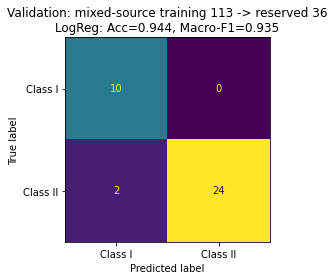


Saved confusion matrix:
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_Model\validation36_confusion_matrix_mixed_source_training113_7ind.png

Validation metrics by source:


,source,n_samples,accuracy,mean_prediction_confidence,balanced_accuracy,macro_f1
0,A_original,24,1.000000,0.953121,NaN,NaN
1,B_second,12,0.833333,0.798838,0.5,0.454545



Validation metrics by source/treatment:


,source,treatment,n_samples,accuracy,mean_prediction_confidence,balanced_accuracy,macro_f1
0,A_original,A_original,24,1.00,0.953121,NaN,NaN
1,B_second,150% N,4,1.00,0.758910,NaN,NaN
2,B_second,50% water,4,0.75,0.743929,0.5,0.428571
3,B_second,Control,4,0.75,0.893675,0.5,0.428571



Training vs validation class distribution:


,source,class_name,n_train,n_validation
0,A_original,Class I,1,0.0
1,A_original,Class II,88,24.0
2,B_second,Class I,15,10.0
3,B_second,Class II,9,2.0



All validation outputs saved to:
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_Model


In [2]:
# ============================================================
# Validation on reserved 36 samples
#
# Training model:
#   mixed-source 113 samples = 89 A + 24 B
#
# Validation:
#   reserved 36 samples = 24 A + 12 B
#
# Important:
#   Validation samples are NOT used to fit scaler, KMeans2, or model.
#   Their reference labels are assigned by the training-fitted scaler + KMeans2.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# ============================================================
# 1. Prepare validation quality table
# ============================================================

quality_val = quality_all[
    quality_all["global_sample_id"].isin(val_ids)
].copy()

if quality_val["global_sample_id"].nunique() != 36:
    raise ValueError(
        f"Validation quality table should contain 36 samples, "
        f"but got {quality_val['global_sample_id'].nunique()}."
    )

print("\nValidation sample composition:")
print(quality_val.groupby(["source", "treatment"]).size())

print("\nValidation source distribution:")
print(quality_val["source"].value_counts())

display(quality_val.head())


# ============================================================
# 2. Assign validation reference labels using training-fitted KMeans2
# ============================================================

Q_val_scaled = quality_scaler.transform(quality_val[QUALITY_COLS].values)

raw_val_labels = kmeans2.predict(Q_val_scaled)

ordered_val_labels = np.array([
    raw_to_ordered[int(x)]
    for x in raw_val_labels
])

quality_val["cluster_raw"] = raw_val_labels
quality_val["y_true"] = ordered_val_labels
quality_val["class_name"] = quality_val["y_true"].map({
    0: "Class I",
    1: "Class II",
})

print("\nValidation reference class distribution:")
print(quality_val["class_name"].value_counts().sort_index())

print("\nValidation class distribution by source:")
print(quality_val.groupby(["source", "class_name"]).size())

print("\nValidation class distribution by source/treatment:")
print(quality_val.groupby(["source", "treatment", "class_name"]).size())

quality_val.to_csv(
    OUT_DIR / "validation36_reference_labels_from_training_kmeans2_7ind.csv",
    index=False
)


# ============================================================
# 3. Prepare validation spectra
# ============================================================

df_val_patches = df_all_spectra[
    df_all_spectra["global_sample_id"].isin(val_ids)
].copy()

if df_val_patches["global_sample_id"].nunique() != 36:
    raise ValueError(
        f"Validation patch data should contain 36 samples, "
        f"but got {df_val_patches['global_sample_id'].nunique()}."
    )

X_val = df_val_patches[wl_cols].values.astype(float)

print("\nValidation patch data:")
print("Validation samples:", df_val_patches["global_sample_id"].nunique())
print("Validation patches:", df_val_patches.shape[0])


# ============================================================
# 4. Predict validation samples from spectra
# ============================================================

proba_raw_val = final_model.predict_proba(X_val)

class_values = sorted(np.unique(y_train_all))
model_classes = list(final_model.classes_)

proba_val = np.zeros((proba_raw_val.shape[0], len(class_values)))

for j, c in enumerate(model_classes):
    full_j = class_values.index(int(c))
    proba_val[:, full_j] = proba_raw_val[:, j]

validation_pred = aggregate_patch_probabilities_to_sample(
    patch_df=df_val_patches[["global_sample_id", "source", "sample_id"]].copy(),
    patch_proba=proba_val,
    class_values=class_values,
)

validation_pred["pred_class_name"] = validation_pred["y_pred"].map({
    0: "Class I",
    1: "Class II",
})

validation_results = validation_pred.merge(
    quality_val[
        ["global_sample_id", "source", "sample_id", "treatment",
         "y_true", "class_name"] + QUALITY_COLS
    ],
    on=["global_sample_id", "source", "sample_id"],
    how="inner"
)

validation_results = validation_results.rename(columns={
    "class_name": "true_class_name"
})

validation_results["correct"] = (
    validation_results["y_pred"] == validation_results["y_true"]
)

print("\nValidation sample-level predictions:")
display(validation_results.sort_values(["source", "sample_id"]))

validation_results.to_csv(
    OUT_DIR / "validation36_predictions_mixed_source_training113_7ind.csv",
    index=False
)


# ============================================================
# 5. Overall validation metrics
# ============================================================

y_true_val = validation_results["y_true"].values.astype(int)
y_pred_val = validation_results["y_pred"].values.astype(int)

validation_metrics = {
    "n_samples": validation_results["global_sample_id"].nunique(),
    "accuracy": accuracy_score(y_true_val, y_pred_val),
    "balanced_accuracy": balanced_accuracy_score(y_true_val, y_pred_val),
    "macro_f1": f1_score(y_true_val, y_pred_val, average="macro"),
    "weighted_f1": f1_score(y_true_val, y_pred_val, average="weighted"),
    "model": best_model_name,
    "scenario": "mixed_source_train113_validation36_7ind",
}

validation_metrics_df = pd.DataFrame([validation_metrics])

print("\n" + "=" * 90)
print("Validation performance: mixed-source training 113 -> reserved validation 36")
print("=" * 90)
display(validation_metrics_df)

print("\nValidation classification report:")
print(
    classification_report(
        y_true_val,
        y_pred_val,
        target_names=["Class I", "Class II"],
        digits=3,
    )
)

validation_metrics_df.to_csv(
    OUT_DIR / "validation36_metrics_mixed_source_training113_7ind.csv",
    index=False
)


# ============================================================
# 6. Confusion matrix
# ============================================================

cm_val = confusion_matrix(
    y_true_val,
    y_pred_val,
    labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(5, 4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=["Class I", "Class II"],
)

disp.plot(ax=ax, values_format="d", colorbar=False)

ax.set_title(
    "Validation: mixed-source training 113 -> reserved 36\n"
    f"{best_model_name}: Acc={validation_metrics['accuracy']:.3f}, "
    f"Macro-F1={validation_metrics['macro_f1']:.3f}"
)

plt.tight_layout()

cm_path = OUT_DIR / "validation36_confusion_matrix_mixed_source_training113_7ind.png"
plt.savefig(cm_path, dpi=300)
plt.show()

print("\nSaved confusion matrix:")
print(cm_path)


# ============================================================
# 7. Validation metrics by source
# ============================================================

source_rows = []

for source, sub in validation_results.groupby("source"):
    y_t = sub["y_true"].values.astype(int)
    y_p = sub["y_pred"].values.astype(int)

    row = {
        "source": source,
        "n_samples": sub["global_sample_id"].nunique(),
        "accuracy": accuracy_score(y_t, y_p),
        "mean_prediction_confidence": sub["prediction_confidence"].mean(),
    }

    if len(np.unique(y_t)) > 1:
        row["balanced_accuracy"] = balanced_accuracy_score(y_t, y_p)
        row["macro_f1"] = f1_score(y_t, y_p, average="macro")
    else:
        row["balanced_accuracy"] = np.nan
        row["macro_f1"] = np.nan

    source_rows.append(row)

source_metrics_df = pd.DataFrame(source_rows)

print("\nValidation metrics by source:")
display(source_metrics_df)

source_metrics_df.to_csv(
    OUT_DIR / "validation36_metrics_by_source_7ind.csv",
    index=False
)


# ============================================================
# 8. Validation metrics by treatment
# ============================================================

treatment_rows = []

for (source, treatment), sub in validation_results.groupby(["source", "treatment"]):
    y_t = sub["y_true"].values.astype(int)
    y_p = sub["y_pred"].values.astype(int)

    row = {
        "source": source,
        "treatment": treatment,
        "n_samples": sub["global_sample_id"].nunique(),
        "accuracy": accuracy_score(y_t, y_p),
        "mean_prediction_confidence": sub["prediction_confidence"].mean(),
    }

    if len(np.unique(y_t)) > 1:
        row["balanced_accuracy"] = balanced_accuracy_score(y_t, y_p)
        row["macro_f1"] = f1_score(y_t, y_p, average="macro")
    else:
        row["balanced_accuracy"] = np.nan
        row["macro_f1"] = np.nan

    treatment_rows.append(row)

treatment_metrics_df = pd.DataFrame(treatment_rows)

print("\nValidation metrics by source/treatment:")
display(treatment_metrics_df)

treatment_metrics_df.to_csv(
    OUT_DIR / "validation36_metrics_by_source_treatment_7ind.csv",
    index=False
)


# ============================================================
# 9. Compare training vs validation class distribution
# ============================================================

train_class_dist = (
    quality_train
    .groupby(["source", "class_name"])
    .size()
    .reset_index(name="n_train")
)

val_class_dist = (
    quality_val
    .groupby(["source", "class_name"])
    .size()
    .reset_index(name="n_validation")
)

class_dist_compare = train_class_dist.merge(
    val_class_dist,
    on=["source", "class_name"],
    how="outer"
).fillna(0)

print("\nTraining vs validation class distribution:")
display(class_dist_compare)

class_dist_compare.to_csv(
    OUT_DIR / "training_vs_validation_class_distribution_7ind.csv",
    index=False
)


# ============================================================
# 10. Save short text summary
# ============================================================

summary_txt = f"""
Mixed-source validation summary

Training set:
- 89 samples from Source A
- 24 samples from Source B
- Total training samples: 113

Validation set:
- 24 samples from Source A
- 12 samples from Source B
- Total validation samples: 36

Quality indicators:
{QUALITY_COLS}

KMeans2:
- Fitted only on training 113 samples
- Validation labels assigned by training-fitted scaler and KMeans2 centers

Best model:
{best_model_name}

Validation performance:
- Accuracy: {validation_metrics['accuracy']:.3f}
- Balanced accuracy: {validation_metrics['balanced_accuracy']:.3f}
- Macro-F1: {validation_metrics['macro_f1']:.3f}
- Weighted-F1: {validation_metrics['weighted_f1']:.3f}
"""

with open(
    OUT_DIR / "validation36_summary_mixed_source_training113_7ind.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(summary_txt)

print("\nAll validation outputs saved to:")
print(OUT_DIR)

Repeated validation output folder: D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_RepeatedValidation
Number of repeats: 50
Models: ['LogReg', 'SVM_RBF', 'RandomForest', 'ExtraTrees', 'SoftVoting']

Repeated validation model: LogReg
Finished 10/50 repeats for LogReg
Finished 20/50 repeats for LogReg
Finished 30/50 repeats for LogReg
Finished 40/50 repeats for LogReg
Finished 50/50 repeats for LogReg

Repeated validation model: SVM_RBF
Finished 10/50 repeats for SVM_RBF
Finished 20/50 repeats for SVM_RBF
Finished 30/50 repeats for SVM_RBF
Finished 40/50 repeats for SVM_RBF
Finished 50/50 repeats for SVM_RBF

Repeated validation model: RandomForest
Finished 10/50 repeats for RandomForest
Finished 20/50 repeats for RandomForest
Finished 30/50 repeats for RandomForest
Finished 40/50 repeats for RandomForest
Finished 50/50 repeats for RandomForest

Repeated validation model: ExtraTrees
Finished 10/50 repeats for ExtraTrees
Finished 20/50 repeats for ExtraTrees
F

,model,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_min,balanced_accuracy_max,macro_f1_mean,...,mean_prediction_confidence_min,mean_prediction_confidence_max,validation_Class_I_n_mean,validation_Class_I_n_std,validation_Class_I_n_min,validation_Class_I_n_max,validation_Class_II_n_mean,validation_Class_II_n_std,validation_Class_II_n_min,validation_Class_II_n_max
0,LogReg,0.893889,0.037516,0.805556,1.000000,0.915624,0.040397,0.811538,1.000000,0.866414,...,0.896341,0.967917,24.16,7.186609,7,31,11.84,7.186609,5,29
1,SoftVoting,0.878333,0.044149,0.777778,0.972222,0.868305,0.074437,0.685185,0.980000,0.838707,...,0.864873,0.961090,24.16,7.186609,7,31,11.84,7.186609,5,29
2,ExtraTrees,0.867778,0.041453,0.777778,0.972222,0.815355,0.074334,0.645320,0.954545,0.812484,...,0.862597,0.934036,24.16,7.186609,7,31,11.84,7.186609,5,29
3,SVM_RBF,0.861667,0.049401,0.750000,0.972222,0.808100,0.090993,0.580769,0.961538,0.801756,...,0.892381,0.992429,24.16,7.186609,7,31,11.84,7.186609,5,29
4,RandomForest,0.863889,0.045678,0.777778,0.972222,0.799015,0.084927,0.591133,0.954545,0.801537,...,0.868027,0.943382,24.16,7.186609,7,31,11.84,7.186609,5,29



Formatted summary:
LogReg: Accuracy=0.894 ± 0.038; Balanced accuracy=0.916 ± 0.040; Macro-F1=0.866 ± 0.053; Weighted-F1=0.900 ± 0.034
SoftVoting: Accuracy=0.878 ± 0.044; Balanced accuracy=0.868 ± 0.074; Macro-F1=0.839 ± 0.068; Weighted-F1=0.882 ± 0.044
ExtraTrees: Accuracy=0.868 ± 0.041; Balanced accuracy=0.815 ± 0.074; Macro-F1=0.812 ± 0.068; Weighted-F1=0.866 ± 0.043
SVM_RBF: Accuracy=0.862 ± 0.049; Balanced accuracy=0.808 ± 0.091; Macro-F1=0.802 ± 0.083; Weighted-F1=0.860 ± 0.054
RandomForest: Accuracy=0.864 ± 0.046; Balanced accuracy=0.799 ± 0.085; Macro-F1=0.802 ± 0.078; Weighted-F1=0.860 ± 0.050

Saved model summary:
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_RepeatedValidation\repeated_validation_summary_by_model.csv

Best repeated-validation model by mean macro-F1: LogReg


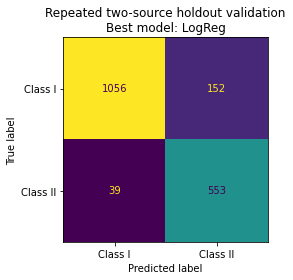


Aggregated classification report for best model:
              precision    recall  f1-score   support

     Class I      0.964     0.874     0.917      1208
    Class II      0.784     0.934     0.853       592

    accuracy                          0.894      1800
   macro avg      0.874     0.904     0.885      1800
weighted avg      0.905     0.894     0.896      1800


Saved confusion matrix:
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_RepeatedValidation\best_model_aggregated_confusion_matrix.png

Best model metrics by source:


accuracy                          balanced_accuracy            \
                mean       std       min  max              mean       std   
source                                                                      
A_original  0.994167  0.016857  0.916667  1.0          0.495652  0.009722   
B_second    0.693333  0.121918  0.416667  1.0          0.484321  0.038672   

                                macro_f1                                \
                 min       max      mean       std       min       max   
source                                                                   
A_original  0.478261  0.500000  0.487142  0.004964  0.478261  0.489362   
B_second    0.350000  0.528571  0.407436  0.038774  0.294118  0.495798   

           mean_prediction_confidence                                
                                 mean       std       min       max  
source                                                               
A_original                   0.969521  0.023755  0.898920  0.991361  
B_second                     0.863239  0.050837  0.746564  0.990295


Saved source-level metrics:
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_RepeatedValidation\best_model_metrics_by_source_each_repeat.csv
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_RepeatedValidation\best_model_metrics_by_source_summary.csv

Best model metrics by B treatment:


accuracy                      balanced_accuracy                      \
              mean       std   min  max              mean       std       min   
treatment                                                                       
150% N       0.685  0.213152  0.25  1.0          0.491667  0.036787  0.333333   
50% water    0.570  0.182388  0.25  1.0          0.477778  0.089541  0.250000   
Control      0.825  0.161703  0.50  1.0          0.500000  0.000000  0.500000   

                     macro_f1                                \
                max      mean       std       min       max   
treatment                                                     
150% N     0.500000  0.374762  0.073567  0.200000  0.428571   
50% water  0.833333  0.356508  0.090622  0.200000  0.733333   
Control    0.500000  0.412698  0.036100  0.333333  0.428571   

          mean_prediction_confidence                                
                                mean       std       min       max  
treatment                                                           
150% N                      0.881028  0.071321  0.690251  0.998714  
50% water                   0.806340  0.096187  0.588189  0.979168  
Control                     0.902350  0.048184  0.730088  0.993004


Saved B-treatment metrics:
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_RepeatedValidation\best_model_B_treatment_metrics_each_repeat.csv
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_RepeatedValidation\best_model_B_treatment_metrics_summary.csv


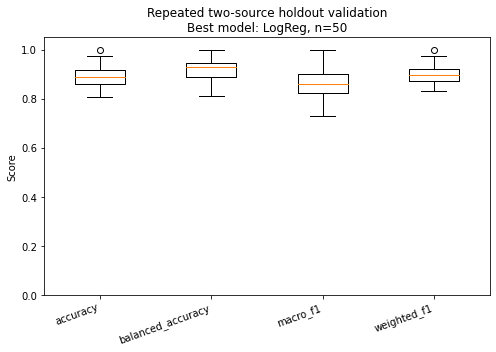


Saved metric distribution plot:
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_RepeatedValidation\best_model_metric_distribution_boxplot.png

Saved text summary:
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_RepeatedValidation\repeated_validation_summary.txt

Repeated two-source holdout validation finished.
All outputs saved to:
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_RepeatedValidation


In [3]:
# ============================================================
# Repeated two-source holdout validation
#
# Each repeat:
#   Training:
#       89 samples from A
#       24 samples from B = 8 Control + 8 150% N + 8 50% water
#       Total = 113
#
#   Validation:
#       24 samples from A
#       12 samples from B = 4 Control + 4 150% N + 4 50% water
#       Total = 36
#
# KMeans2 is fitted only on the training 113 samples in each repeat.
# Validation labels are assigned using the training-fitted scaler + KMeans2.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# ============================================================
# 0. Output folder and settings
# ============================================================

REPEAT_OUT_DIR = PROJECT_DIR / "Pea_TwoSource_Mixed113_RepeatedValidation"
REPEAT_OUT_DIR.mkdir(parents=True, exist_ok=True)

N_REPEATS = 50

MODEL_NAMES_TO_RUN = [
    "LogReg",
    "SVM_RBF",
    "RandomForest",
    "ExtraTrees",
    "SoftVoting",
]

print("Repeated validation output folder:", REPEAT_OUT_DIR)
print("Number of repeats:", N_REPEATS)
print("Models:", MODEL_NAMES_TO_RUN)


# ============================================================
# 1. Helper function: one repeated split
# ============================================================

def create_two_source_split_for_repeat(repeat_id, random_state=42):
    """
    Create one mixed-source split.

    Training:
        A 89 + B 24

    Validation:
        A 24 + B 12

    B validation is balanced by treatment:
        4 Control + 4 150% N + 4 50% water
    """

    rng = np.random.default_rng(random_state + repeat_id)

    # Source A: choose 24 validation, remaining 89 training
    a_ids = np.array(sorted(quality_a["global_sample_id"].unique()))

    if len(a_ids) != 113:
        raise ValueError(f"Source A should contain 113 samples, but got {len(a_ids)}.")

    a_val_ids = rng.choice(a_ids, size=24, replace=False)
    a_train_ids = np.array([x for x in a_ids if x not in a_val_ids])

    # Source B: choose 4 validation from each treatment
    b_val_ids = []
    b_train_ids = []

    for treatment in ["Control", "150% N", "50% water"]:
        ids_t = np.array(sorted(
            quality_b.loc[
                quality_b["treatment"] == treatment,
                "global_sample_id"
            ].unique()
        ))

        if len(ids_t) != 12:
            raise ValueError(
                f"Source B treatment {treatment} should contain 12 samples, "
                f"but got {len(ids_t)}."
            )

        val_t = rng.choice(ids_t, size=4, replace=False)
        train_t = np.array([x for x in ids_t if x not in val_t])

        b_val_ids.extend(val_t.tolist())
        b_train_ids.extend(train_t.tolist())

    train_ids_repeat = sorted(a_train_ids.tolist() + b_train_ids)
    val_ids_repeat = sorted(a_val_ids.tolist() + b_val_ids)

    if len(train_ids_repeat) != 113:
        raise ValueError(f"Training set should contain 113 samples, but got {len(train_ids_repeat)}.")

    if len(val_ids_repeat) != 36:
        raise ValueError(f"Validation set should contain 36 samples, but got {len(val_ids_repeat)}.")

    return train_ids_repeat, val_ids_repeat


# ============================================================
# 2. Helper function: run one split and one model
# ============================================================

def run_one_repeat_one_model(repeat_id, model_name, model_template):
    """
    Run one repeated split and evaluate one classifier.
    """

    # --------------------------------------------------------
    # 2.1 Create train / validation split
    # --------------------------------------------------------

    train_ids_repeat, val_ids_repeat = create_two_source_split_for_repeat(
        repeat_id=repeat_id,
        random_state=RANDOM_STATE
    )

    # --------------------------------------------------------
    # 2.2 Fit KMeans2 on training 113 quality data only
    # --------------------------------------------------------

    quality_train_repeat = quality_all[
        quality_all["global_sample_id"].isin(train_ids_repeat)
    ].copy()

    quality_val_repeat = quality_all[
        quality_all["global_sample_id"].isin(val_ids_repeat)
    ].copy()

    if quality_train_repeat["global_sample_id"].nunique() != 113:
        raise ValueError("Training quality table does not contain 113 samples.")

    if quality_val_repeat["global_sample_id"].nunique() != 36:
        raise ValueError("Validation quality table does not contain 36 samples.")

    scaler_repeat = StandardScaler()
    Q_train_scaled = scaler_repeat.fit_transform(
        quality_train_repeat[QUALITY_COLS].values
    )

    kmeans_repeat = KMeans(
        n_clusters=2,
        random_state=RANDOM_STATE + repeat_id,
        n_init=50
    )

    raw_train_labels = kmeans_repeat.fit_predict(Q_train_scaled)

    raw_to_ordered_repeat = remap_kmeans_labels_by_protein(
        kmeans=kmeans_repeat,
        quality_cols=QUALITY_COLS
    )

    ordered_train_labels = np.array([
        raw_to_ordered_repeat[int(x)]
        for x in raw_train_labels
    ])

    quality_train_repeat["cluster_raw"] = raw_train_labels
    quality_train_repeat["y_true"] = ordered_train_labels
    quality_train_repeat["class_name"] = quality_train_repeat["y_true"].map({
        0: "Class I",
        1: "Class II",
    })

    # Assign validation reference labels using training-fitted scaler + KMeans
    Q_val_scaled = scaler_repeat.transform(
        quality_val_repeat[QUALITY_COLS].values
    )

    raw_val_labels = kmeans_repeat.predict(Q_val_scaled)

    ordered_val_labels = np.array([
        raw_to_ordered_repeat[int(x)]
        for x in raw_val_labels
    ])

    quality_val_repeat["cluster_raw"] = raw_val_labels
    quality_val_repeat["y_true"] = ordered_val_labels
    quality_val_repeat["class_name"] = quality_val_repeat["y_true"].map({
        0: "Class I",
        1: "Class II",
    })

    # --------------------------------------------------------
    # 2.3 Prepare spectra
    # --------------------------------------------------------

    label_map_train = quality_train_repeat.set_index("global_sample_id")["y_true"].to_dict()

    df_train_patches_repeat = df_all_spectra[
        df_all_spectra["global_sample_id"].isin(train_ids_repeat)
    ].copy()

    df_val_patches_repeat = df_all_spectra[
        df_all_spectra["global_sample_id"].isin(val_ids_repeat)
    ].copy()

    df_train_patches_repeat["y"] = (
        df_train_patches_repeat["global_sample_id"]
        .map(label_map_train)
        .astype(int)
    )

    X_train_repeat = df_train_patches_repeat[wl_cols].values.astype(float)
    y_train_repeat = df_train_patches_repeat["y"].values.astype(int)

    X_val_repeat = df_val_patches_repeat[wl_cols].values.astype(float)

    # --------------------------------------------------------
    # 2.4 Fit classifier and predict validation patches
    # --------------------------------------------------------

    model = clone(model_template)
    model.fit(X_train_repeat, y_train_repeat)

    proba_raw_val = model.predict_proba(X_val_repeat)

    class_values = sorted(np.unique(y_train_repeat))
    model_classes = list(model.classes_)

    proba_val = np.zeros((proba_raw_val.shape[0], len(class_values)))

    for j, c in enumerate(model_classes):
        full_j = class_values.index(int(c))
        proba_val[:, full_j] = proba_raw_val[:, j]

    validation_pred = aggregate_patch_probabilities_to_sample(
        patch_df=df_val_patches_repeat[
            ["global_sample_id", "source", "sample_id"]
        ].copy(),
        patch_proba=proba_val,
        class_values=class_values,
    )

    validation_pred["pred_class_name"] = validation_pred["y_pred"].map({
        0: "Class I",
        1: "Class II",
    })

    validation_results_repeat = validation_pred.merge(
        quality_val_repeat[
            ["global_sample_id", "source", "sample_id", "treatment",
             "y_true", "class_name"] + QUALITY_COLS
        ],
        on=["global_sample_id", "source", "sample_id"],
        how="inner"
    )

    validation_results_repeat = validation_results_repeat.rename(columns={
        "class_name": "true_class_name"
    })

    validation_results_repeat["correct"] = (
        validation_results_repeat["y_pred"] ==
        validation_results_repeat["y_true"]
    )

    validation_results_repeat["repeat"] = repeat_id
    validation_results_repeat["model"] = model_name

    # --------------------------------------------------------
    # 2.5 Metrics
    # --------------------------------------------------------

    y_true = validation_results_repeat["y_true"].values.astype(int)
    y_pred = validation_results_repeat["y_pred"].values.astype(int)

    metrics = {
        "repeat": repeat_id,
        "model": model_name,
        "n_train_samples": len(train_ids_repeat),
        "n_validation_samples": len(val_ids_repeat),
        "train_A_n": sum([x.startswith("A_") for x in train_ids_repeat]),
        "train_B_n": sum([x.startswith("B_") for x in train_ids_repeat]),
        "validation_A_n": sum([x.startswith("A_") for x in val_ids_repeat]),
        "validation_B_n": sum([x.startswith("B_") for x in val_ids_repeat]),
        "train_Class_I_n": int((quality_train_repeat["y_true"] == 0).sum()),
        "train_Class_II_n": int((quality_train_repeat["y_true"] == 1).sum()),
        "validation_Class_I_n": int((quality_val_repeat["y_true"] == 0).sum()),
        "validation_Class_II_n": int((quality_val_repeat["y_true"] == 1).sum()),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "mean_prediction_confidence": validation_results_repeat["prediction_confidence"].mean(),
    }

    return metrics, validation_results_repeat, quality_train_repeat, quality_val_repeat


# ============================================================
# 3. Run repeated validation for all models
# ============================================================

all_metrics = []
all_predictions = []
all_validation_labels = []

for model_name in MODEL_NAMES_TO_RUN:
    if model_name not in models:
        raise ValueError(
            f"{model_name} not found in models. Available models: {list(models.keys())}"
        )

    print("\n" + "=" * 90)
    print("Repeated validation model:", model_name)
    print("=" * 90)

    for repeat_id in range(N_REPEATS):
        metrics, validation_results_repeat, quality_train_repeat, quality_val_repeat = run_one_repeat_one_model(
            repeat_id=repeat_id,
            model_name=model_name,
            model_template=models[model_name],
        )

        all_metrics.append(metrics)
        all_predictions.append(validation_results_repeat)

        temp_val_labels = quality_val_repeat[
            ["global_sample_id", "source", "sample_id", "treatment",
             "y_true", "class_name"] + QUALITY_COLS
        ].copy()
        temp_val_labels["repeat"] = repeat_id
        temp_val_labels["model"] = model_name
        all_validation_labels.append(temp_val_labels)

        if (repeat_id + 1) % 10 == 0:
            print(f"Finished {repeat_id + 1}/{N_REPEATS} repeats for {model_name}")


metrics_df = pd.DataFrame(all_metrics)
predictions_df = pd.concat(all_predictions, axis=0, ignore_index=True)
validation_labels_df = pd.concat(all_validation_labels, axis=0, ignore_index=True)

metrics_path = REPEAT_OUT_DIR / "repeated_validation_metrics_each_repeat.csv"
predictions_path = REPEAT_OUT_DIR / "repeated_validation_sample_predictions.csv"
labels_path = REPEAT_OUT_DIR / "repeated_validation_reference_labels.csv"

metrics_df.to_csv(metrics_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
validation_labels_df.to_csv(labels_path, index=False)

print("\nSaved raw repeated-validation outputs:")
print(metrics_path)
print(predictions_path)
print(labels_path)


# ============================================================
# 4. Summary by model
# ============================================================

summary_by_model = (
    metrics_df
    .groupby("model")[
        ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1",
         "mean_prediction_confidence",
         "validation_Class_I_n", "validation_Class_II_n"]
    ]
    .agg(["mean", "std", "min", "max"])
)

summary_by_model.columns = [
    f"{metric}_{stat}"
    for metric, stat in summary_by_model.columns
]

summary_by_model = summary_by_model.reset_index()

summary_by_model = summary_by_model.sort_values(
    ["macro_f1_mean", "balanced_accuracy_mean", "accuracy_mean"],
    ascending=False
).reset_index(drop=True)

summary_path = REPEAT_OUT_DIR / "repeated_validation_summary_by_model.csv"
summary_by_model.to_csv(summary_path, index=False)

print("\nRepeated validation summary by model:")
display(summary_by_model)

print("\nFormatted summary:")
for _, row in summary_by_model.iterrows():
    print(
        f"{row['model']}: "
        f"Accuracy={row['accuracy_mean']:.3f} ± {row['accuracy_std']:.3f}; "
        f"Balanced accuracy={row['balanced_accuracy_mean']:.3f} ± {row['balanced_accuracy_std']:.3f}; "
        f"Macro-F1={row['macro_f1_mean']:.3f} ± {row['macro_f1_std']:.3f}; "
        f"Weighted-F1={row['weighted_f1_mean']:.3f} ± {row['weighted_f1_std']:.3f}"
    )

print("\nSaved model summary:")
print(summary_path)


# ============================================================
# 5. Best model aggregated confusion matrix
# ============================================================

best_repeat_model = summary_by_model.iloc[0]["model"]

print("\nBest repeated-validation model by mean macro-F1:", best_repeat_model)

best_predictions = predictions_df[
    predictions_df["model"] == best_repeat_model
].copy()

y_true_all = best_predictions["y_true"].values.astype(int)
y_pred_all = best_predictions["y_pred"].values.astype(int)

cm = confusion_matrix(
    y_true_all,
    y_pred_all,
    labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(5, 4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class I", "Class II"]
)

disp.plot(ax=ax, values_format="d", colorbar=False)

ax.set_title(
    "Repeated two-source holdout validation\n"
    f"Best model: {best_repeat_model}"
)

plt.tight_layout()

cm_path = REPEAT_OUT_DIR / "best_model_aggregated_confusion_matrix.png"
plt.savefig(cm_path, dpi=300)
plt.show()

print("\nAggregated classification report for best model:")
print(
    classification_report(
        y_true_all,
        y_pred_all,
        target_names=["Class I", "Class II"],
        digits=3,
    )
)

print("\nSaved confusion matrix:")
print(cm_path)


# ============================================================
# 6. Metrics by source for best model
# ============================================================

source_rows = []

best_predictions = predictions_df[
    predictions_df["model"] == best_repeat_model
].copy()

for (repeat_id, source), sub in best_predictions.groupby(["repeat", "source"]):
    y_t = sub["y_true"].values.astype(int)
    y_p = sub["y_pred"].values.astype(int)

    row = {
        "repeat": repeat_id,
        "source": source,
        "n_samples": sub["global_sample_id"].nunique(),
        "accuracy": accuracy_score(y_t, y_p),
        "mean_prediction_confidence": sub["prediction_confidence"].mean(),
    }

    if len(np.unique(y_t)) > 1:
        row["balanced_accuracy"] = balanced_accuracy_score(y_t, y_p)
        row["macro_f1"] = f1_score(y_t, y_p, average="macro")
    else:
        row["balanced_accuracy"] = np.nan
        row["macro_f1"] = np.nan

    source_rows.append(row)

source_metrics_df = pd.DataFrame(source_rows)

source_summary = (
    source_metrics_df
    .groupby("source")[
        ["accuracy", "balanced_accuracy", "macro_f1", "mean_prediction_confidence"]
    ]
    .agg(["mean", "std", "min", "max"])
)

source_metrics_path = REPEAT_OUT_DIR / "best_model_metrics_by_source_each_repeat.csv"
source_summary_path = REPEAT_OUT_DIR / "best_model_metrics_by_source_summary.csv"

source_metrics_df.to_csv(source_metrics_path, index=False)
source_summary.to_csv(source_summary_path)

print("\nBest model metrics by source:")
display(source_summary)

print("\nSaved source-level metrics:")
print(source_metrics_path)
print(source_summary_path)


# ============================================================
# 7. Metrics by B treatment for best model
# ============================================================

treatment_rows = []

best_predictions_b = best_predictions[
    best_predictions["source"] == "B_second"
].copy()

for (repeat_id, treatment), sub in best_predictions_b.groupby(["repeat", "treatment"]):
    y_t = sub["y_true"].values.astype(int)
    y_p = sub["y_pred"].values.astype(int)

    row = {
        "repeat": repeat_id,
        "treatment": treatment,
        "n_samples": sub["global_sample_id"].nunique(),
        "accuracy": accuracy_score(y_t, y_p),
        "mean_prediction_confidence": sub["prediction_confidence"].mean(),
    }

    if len(np.unique(y_t)) > 1:
        row["balanced_accuracy"] = balanced_accuracy_score(y_t, y_p)
        row["macro_f1"] = f1_score(y_t, y_p, average="macro")
    else:
        row["balanced_accuracy"] = np.nan
        row["macro_f1"] = np.nan

    treatment_rows.append(row)

treatment_metrics_df = pd.DataFrame(treatment_rows)

treatment_summary = (
    treatment_metrics_df
    .groupby("treatment")[
        ["accuracy", "balanced_accuracy", "macro_f1", "mean_prediction_confidence"]
    ]
    .agg(["mean", "std", "min", "max"])
)

treatment_metrics_path = REPEAT_OUT_DIR / "best_model_B_treatment_metrics_each_repeat.csv"
treatment_summary_path = REPEAT_OUT_DIR / "best_model_B_treatment_metrics_summary.csv"

treatment_metrics_df.to_csv(treatment_metrics_path, index=False)
treatment_summary.to_csv(treatment_summary_path)

print("\nBest model metrics by B treatment:")
display(treatment_summary)

print("\nSaved B-treatment metrics:")
print(treatment_metrics_path)
print(treatment_summary_path)


# ============================================================
# 8. Plot metric distribution across repeats
# ============================================================

plot_model_df = metrics_df[
    metrics_df["model"] == best_repeat_model
].copy()

fig, ax = plt.subplots(figsize=(7, 5))

metric_names = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]
data_to_plot = [plot_model_df[m].values for m in metric_names]

ax.boxplot(data_to_plot, labels=metric_names)

ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title(
    "Repeated two-source holdout validation\n"
    f"Best model: {best_repeat_model}, n={N_REPEATS}"
)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

boxplot_path = REPEAT_OUT_DIR / "best_model_metric_distribution_boxplot.png"
plt.savefig(boxplot_path, dpi=300)
plt.show()

print("\nSaved metric distribution plot:")
print(boxplot_path)


# ============================================================
# 9. Save text summary
# ============================================================

best_row = summary_by_model.iloc[0]

summary_txt = f"""
Repeated two-source holdout validation summary

Design:
- Total sample pool: Source A 113 + Source B 36 = 149 samples
- Each repeat training set: 89 Source A + 24 Source B = 113 samples
- Each repeat validation set: 24 Source A + 12 Source B = 36 samples
- Source B validation set was treatment-balanced:
  4 Control + 4 150% N + 4 50% water

Quality indicators:
{QUALITY_COLS}

Method:
- Quality scaler and KMeans2 were fitted only on the training 113 samples in each repeat.
- Validation samples were assigned reference labels using the training-fitted scaler and KMeans2 centers.
- Spectral classifiers were trained only on the training 113 samples.
- Validation performance was evaluated on the reserved 36 samples.

Number of repeats:
{N_REPEATS}

Best model:
{best_repeat_model}

Best model repeated-validation performance:
- Accuracy: {best_row['accuracy_mean']:.3f} ± {best_row['accuracy_std']:.3f}
- Balanced accuracy: {best_row['balanced_accuracy_mean']:.3f} ± {best_row['balanced_accuracy_std']:.3f}
- Macro-F1: {best_row['macro_f1_mean']:.3f} ± {best_row['macro_f1_std']:.3f}
- Weighted-F1: {best_row['weighted_f1_mean']:.3f} ± {best_row['weighted_f1_std']:.3f}
"""

summary_txt_path = REPEAT_OUT_DIR / "repeated_validation_summary.txt"

with open(summary_txt_path, "w", encoding="utf-8") as f:
    f.write(summary_txt)

print("\nSaved text summary:")
print(summary_txt_path)

print("\nRepeated two-source holdout validation finished.")
print("All outputs saved to:")
print(REPEAT_OUT_DIR)

Output folder: D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_KMeans2_QualityIndicatorContribution
Loaded quality table:
(149, 11)
A_original    113
B_second       36
Name: source, dtype: int64


,global_sample_id,source,sample_id,treatment,Protein content,Moisture content,Water uptaking capacity,Water binding capacity,Oil binding capacity,Protein solubility,Peak viscosity (RVA)
0,A_1,A_original,1,A_original,25.09375,7.475139,83.910574,96.313318,75.336961,14.986986,216.5
1,A_2,A_original,2,A_original,23.31250,7.085157,92.134487,96.448087,84.088717,18.218004,334.5
2,A_3,A_original,3,A_original,23.34375,5.797493,88.162492,90.197288,73.156020,15.871029,363.0
3,A_4,A_original,4,A_original,22.59375,7.231036,95.473763,92.219968,64.180009,26.492999,342.0
4,A_5,A_original,5,A_original,21.43750,6.903353,82.793809,95.616472,80.637213,17.414737,319.0



Loaded fixed training labels:
Class I     16
Class II    97
Name: class_name, dtype: int64

Fixed KMeans2 quality-indicator contribution:


,quality_indicator,eta_squared,standardized_center_difference,standardized_center_range,anova_F,anova_p,class_0_standardized_mean,class_1_standardized_mean
0,Water uptaking capacity,0.640375,2.295354,2.295354,197.654626,2.102017e-26,-1.970348,0.325006
1,Water binding capacity,0.391938,1.795731,1.795731,71.547181,1.216251e-13,1.541468,-0.254263
2,Moisture content,0.303272,1.579607,1.579607,48.316211,2.623937e-10,1.355946,-0.223661
3,Oil binding capacity,0.159025,1.143839,1.143839,20.989630,1.215175e-05,-0.981880,0.161960
4,Peak viscosity (RVA),0.021773,0.423242,0.423242,2.470562,1.188427e-01,0.363314,-0.059928
5,Protein solubility,0.003178,0.161712,0.161712,0.353938,5.531034e-01,0.138815,-0.022897
6,Protein content,0.002811,0.152063,0.152063,0.312845,5.770661e-01,-0.130532,0.021531



Fixed KMeans2 cluster profile:


Protein content                 Moisture content                  \
                      mean       std count             mean       std count   
class_name                                                                    
Class I          22.517578  1.670554    16         8.335567  0.509472    16   
Class II         22.734536  1.397616    97         6.937457  0.775833    97   

           Water uptaking capacity                  Water binding capacity  \
                              mean        std count                   mean   
class_name                                                                   
Class I                  56.451446  19.916901    16             112.334540   
Class II                 92.607383   6.561192    97              92.364353   

            ...       Oil binding capacity                 Protein solubility  \
            ... count                 mean       std count               mean   
class_name  ...                                                                 
Class I     ...    16            70.916674  9.626702    16          27.434061   
Class II    ...    97            78.827277  5.732832    97          26.800800   

                           Peak viscosity (RVA)                    
                 std count                 mean         std count  
class_name                                                         
Class I     3.856536    16           348.562500  124.251476    16  
Class II    3.958426    97           323.438144   40.561698    97  

[2 rows x 21 columns]

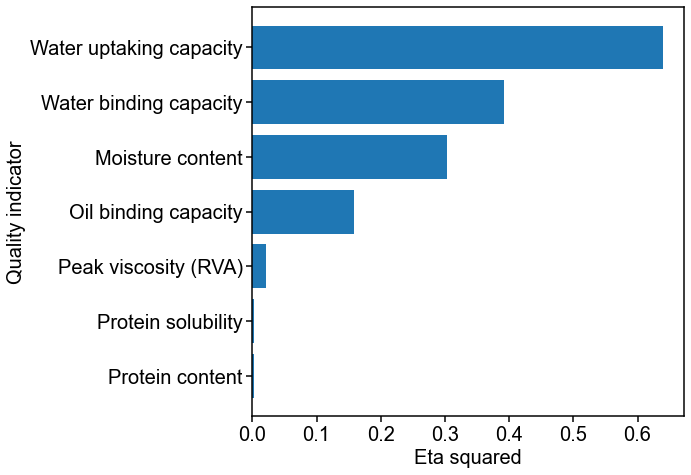

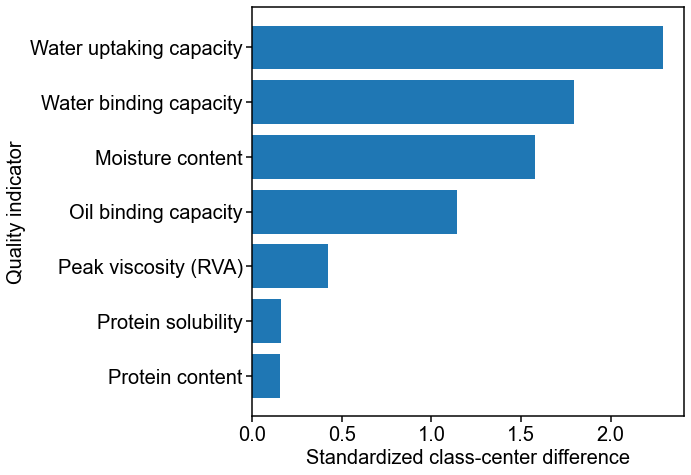


Repeated KMeans2 quality-indicator contribution summary:


,quality_indicator,eta_squared_mean,eta_squared_std,eta_squared_min,eta_squared_max,standardized_center_difference_mean,standardized_center_difference_std,standardized_center_difference_min,standardized_center_difference_max,standardized_center_range_mean,standardized_center_range_std,standardized_center_range_min,standardized_center_range_max,anova_F_mean,anova_F_std,anova_F_min,anova_F_max
0,Water uptaking capacity,0.647101,0.072942,3.868794e-01,0.757561,2.235003,0.213657,1.458596,2.553715,2.235003,0.213657,1.458596,2.553715,214.734836,57.648075,70.041048,346.847993
1,Moisture content,0.388440,0.074748,2.771363e-01,0.699587,1.718162,0.090935,1.535861,2.015060,1.718162,0.090935,1.535861,2.015060,74.508426,34.923800,42.555917,258.491507
2,Water binding capacity,0.276337,0.075470,1.212910e-01,0.519355,1.444619,0.184237,0.839037,1.888227,1.444619,0.184237,0.839037,1.888227,44.233247,18.376547,15.321679,119.939681
3,Oil binding capacity,0.178060,0.060677,2.566124e-02,0.304140,1.157307,0.241809,0.375652,1.673916,1.157307,0.241809,0.375652,1.673916,24.768319,10.031290,2.923417,48.514843
4,Peak viscosity (RVA),0.033832,0.030143,2.249737e-04,0.168897,0.450828,0.245885,0.041955,1.211242,0.450828,0.245885,0.041955,1.211242,4.003687,3.833205,0.024978,22.557463
5,Protein content,0.006699,0.009587,1.449609e-07,0.047007,0.182613,0.129318,0.000998,0.606457,0.182613,0.129318,0.000998,0.606457,0.759123,1.108826,0.000016,5.475157
6,Protein solubility,0.003115,0.005095,3.923432e-06,0.029258,0.123238,0.097318,0.005296,0.490634,0.123238,0.097318,0.005296,0.490634,0.349790,0.578804,0.000436,3.345571


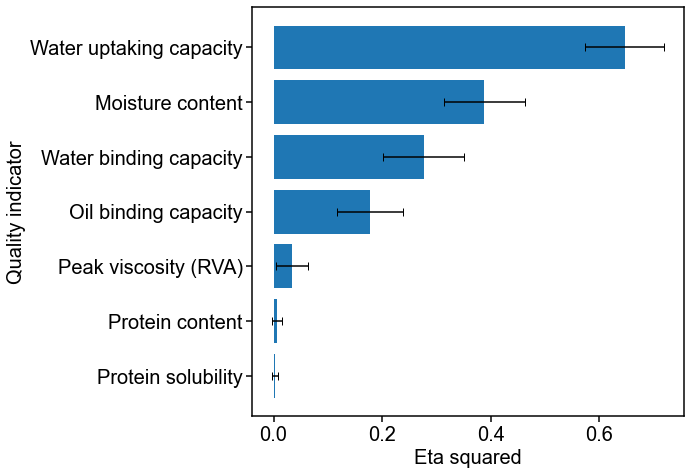

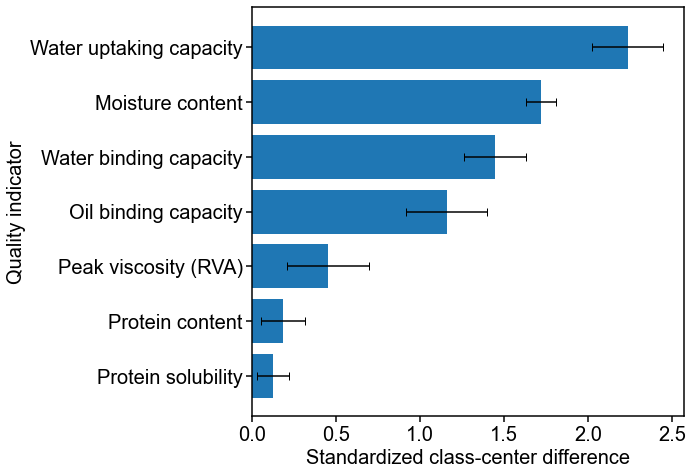


Final ranking based on repeated KMeans2 contribution


,quality_indicator,eta_squared_mean,eta_squared_std,standardized_center_difference_mean,standardized_center_difference_std
0,Water uptaking capacity,0.647101,0.072942,2.235003,0.213657
1,Moisture content,0.388440,0.074748,1.718162,0.090935
2,Water binding capacity,0.276337,0.075470,1.444619,0.184237
3,Oil binding capacity,0.178060,0.060677,1.157307,0.241809
4,Peak viscosity (RVA),0.033832,0.030143,0.450828,0.245885
5,Protein content,0.006699,0.009587,0.182613,0.129318
6,Protein solubility,0.003115,0.005095,0.123238,0.097318



Top indicators by eta squared:
1. Water uptaking capacity: eta² = 0.647 ± 0.073; center difference = 2.235 ± 0.214
2. Moisture content: eta² = 0.388 ± 0.075; center difference = 1.718 ± 0.091
3. Water binding capacity: eta² = 0.276 ± 0.075; center difference = 1.445 ± 0.184
4. Oil binding capacity: eta² = 0.178 ± 0.061; center difference = 1.157 ± 0.242
5. Peak viscosity (RVA): eta² = 0.034 ± 0.030; center difference = 0.451 ± 0.246
6. Protein content: eta² = 0.007 ± 0.010; center difference = 0.183 ± 0.129
7. Protein solubility: eta² = 0.003 ± 0.005; center difference = 0.123 ± 0.097

Saved all outputs to:
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_KMeans2_QualityIndicatorContribution


In [4]:
# ============================================================
# Quality-indicator contribution analysis for overall classification
#
# Purpose:
#   Identify which quality indicators dominate the KMeans-based
#   overall quality classes.
#
# This code analyzes:
#   1. Fixed mixed-source KMeans2 model
#   2. Repeated two-source KMeans2 splits
#
# Main outputs:
#   - eta_squared ranking
#   - standardized center difference ranking
#   - quality cluster profile
#   - contribution plots
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import f_classif

# ============================================================
# 0. Settings
# ============================================================

RANDOM_STATE = 42
KMEANS_N_CLUSTERS = 2
N_REPEATS = 50

PROJECT_DIR = Path(r"D:\LabData\Menglin Han\Menglin Han coding\Pea project")

# Folder from your KMeans2 mixed-source classification model
KMEANS2_MODEL_DIR = PROJECT_DIR / "Pea_TwoSource_Mixed113_Model"

QUALITY_ALL_CSV = KMEANS2_MODEL_DIR / "combined_A_B_quality_all149.csv"
FIXED_TRAIN_LABEL_CSV = KMEANS2_MODEL_DIR / "training113_kmeans2_labels_7ind.csv"

OUT_DIR = PROJECT_DIR / "Pea_TwoSource_Mixed113_KMeans2_QualityIndicatorContribution"
OUT_DIR.mkdir(parents=True, exist_ok=True)

QUALITY_COLS = [
    "Protein content",
    "Moisture content",
    "Water uptaking capacity",
    "Water binding capacity",
    "Oil binding capacity",
    "Protein solubility",
    "Peak viscosity (RVA)",
]

CLASS_NAME_MAP = {
    0: "Class I",
    1: "Class II",
}

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 20
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["xtick.labelsize"] = 20
plt.rcParams["ytick.labelsize"] = 20
plt.rcParams["legend.fontsize"] = 20

print("Output folder:", OUT_DIR)


# ============================================================
# 1. Helper functions
# ============================================================

def remap_kmeans_labels_by_protein(kmeans, quality_cols):
    """
    Order KMeans clusters by protein center.
    Class I  = lower protein-center cluster
    Class II = higher protein-center cluster
    """
    centers = kmeans.cluster_centers_

    protein_idx = quality_cols.index("Protein content")
    order_score = centers[:, protein_idx]

    raw_order = np.argsort(order_score)
    raw_to_ordered = {int(raw): int(new) for new, raw in enumerate(raw_order)}

    return raw_to_ordered


def create_two_source_split_for_repeat(quality_all, repeat_id, random_state=42):
    """
    Training:
        A 89 + B 24 = 113

    Validation:
        A 24 + B 12 = 36

    B validation:
        Control 4 + 150% N 4 + 50% water 4
    """

    rng = np.random.default_rng(random_state + repeat_id)

    quality_a = quality_all[quality_all["source"] == "A_original"].copy()
    quality_b = quality_all[quality_all["source"] == "B_second"].copy()

    a_ids = np.array(sorted(quality_a["global_sample_id"].unique()))

    if len(a_ids) != 113:
        raise ValueError(f"Source A should contain 113 samples, but got {len(a_ids)}.")

    a_val_ids = rng.choice(a_ids, size=24, replace=False)
    a_train_ids = np.array([x for x in a_ids if x not in a_val_ids])

    b_val_ids = []
    b_train_ids = []

    for treatment in ["Control", "150% N", "50% water"]:
        ids_t = np.array(sorted(
            quality_b.loc[
                quality_b["treatment"] == treatment,
                "global_sample_id"
            ].unique()
        ))

        if len(ids_t) != 12:
            raise ValueError(
                f"B treatment {treatment} should contain 12 samples, but got {len(ids_t)}."
            )

        val_t = rng.choice(ids_t, size=4, replace=False)
        train_t = np.array([x for x in ids_t if x not in val_t])

        b_val_ids.extend(val_t.tolist())
        b_train_ids.extend(train_t.tolist())

    train_ids = sorted(a_train_ids.tolist() + b_train_ids)
    val_ids = sorted(a_val_ids.tolist() + b_val_ids)

    return train_ids, val_ids


def fit_kmeans2_on_training_quality(quality_train):
    """
    Fit StandardScaler + KMeans2 only on training quality data.
    """

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(quality_train[QUALITY_COLS].values)

    kmeans = KMeans(
        n_clusters=KMEANS_N_CLUSTERS,
        random_state=RANDOM_STATE,
        n_init=50
    )

    raw_labels = kmeans.fit_predict(X_scaled)

    raw_to_ordered = remap_kmeans_labels_by_protein(
        kmeans=kmeans,
        quality_cols=QUALITY_COLS
    )

    ordered_labels = np.array([
        raw_to_ordered[int(x)]
        for x in raw_labels
    ])

    quality_train_labeled = quality_train.copy()
    quality_train_labeled["cluster_raw"] = raw_labels
    quality_train_labeled["y_true"] = ordered_labels
    quality_train_labeled["class_name"] = quality_train_labeled["y_true"].map(CLASS_NAME_MAP)

    return quality_train_labeled, scaler, kmeans, raw_to_ordered


def calculate_quality_indicator_contribution(quality_labeled, scaler, label_col="y_true"):
    """
    Calculate how much each quality indicator contributes to class separation.

    Outputs:
    - eta_squared:
        Between-class variance / total variance.
        Larger value means the indicator better separates classes.

    - standardized_center_difference:
        Difference between class centers in standardized quality space.
        For KMeans2, this is absolute Class II - Class I center difference.
    """

    df = quality_labeled.copy()

    X_scaled = scaler.transform(df[QUALITY_COLS].values)
    y = df[label_col].values.astype(int)

    contribution_rows = []

    # f_classif gives ANOVA F and p-value
    f_values, p_values = f_classif(X_scaled, y)

    for j, col in enumerate(QUALITY_COLS):
        x = X_scaled[:, j]

        overall_mean = np.mean(x)
        sst = np.sum((x - overall_mean) ** 2)

        ssb = 0.0
        class_means = {}

        for c in sorted(np.unique(y)):
            x_c = x[y == c]
            class_mean = np.mean(x_c)
            class_means[c] = class_mean
            ssb += len(x_c) * (class_mean - overall_mean) ** 2

        eta_squared = ssb / sst if sst > 0 else np.nan

        center_values = np.array([class_means[c] for c in sorted(class_means.keys())])
        standardized_center_range = center_values.max() - center_values.min()

        if KMEANS_N_CLUSTERS == 2:
            standardized_center_difference = abs(class_means[1] - class_means[0])
        else:
            standardized_center_difference = standardized_center_range

        row = {
            "quality_indicator": col,
            "eta_squared": eta_squared,
            "standardized_center_difference": standardized_center_difference,
            "standardized_center_range": standardized_center_range,
            "anova_F": f_values[j],
            "anova_p": p_values[j],
        }

        for c, m in class_means.items():
            row[f"class_{c}_standardized_mean"] = m

        contribution_rows.append(row)

    contribution_df = pd.DataFrame(contribution_rows)

    contribution_df = contribution_df.sort_values(
        ["eta_squared", "standardized_center_difference"],
        ascending=False
    ).reset_index(drop=True)

    return contribution_df


def calculate_cluster_profile(quality_labeled):
    profile = (
        quality_labeled
        .groupby("class_name")[QUALITY_COLS]
        .agg(["mean", "std", "count"])
    )

    return profile


def plot_contribution_bar(contribution_df, value_col, output_path, xlabel):
    plot_df = contribution_df.sort_values(value_col, ascending=True).copy()

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.barh(
        plot_df["quality_indicator"],
        plot_df[value_col]
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Quality indicator")

    ax.tick_params(direction="out", length=6, width=1.5)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_repeated_contribution_summary(summary_df, value_mean_col, value_std_col, output_path, xlabel):
    plot_df = summary_df.sort_values(value_mean_col, ascending=True).copy()

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.barh(
        plot_df["quality_indicator"],
        plot_df[value_mean_col],
        xerr=plot_df[value_std_col],
        capsize=4
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Quality indicator")

    ax.tick_params(direction="out", length=6, width=1.5)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================
# 2. Load quality table
# ============================================================

if not QUALITY_ALL_CSV.exists():
    raise FileNotFoundError(
        f"Cannot find combined quality table:\n{QUALITY_ALL_CSV}\n"
        "Run the KMeans2 mixed-source classification code first."
    )

quality_all = pd.read_csv(QUALITY_ALL_CSV)

required_cols = ["global_sample_id", "source", "sample_id", "treatment"] + QUALITY_COLS

missing_cols = [c for c in required_cols if c not in quality_all.columns]
if len(missing_cols) > 0:
    raise ValueError(f"Missing columns in quality_all: {missing_cols}")

print("Loaded quality table:")
print(quality_all.shape)
print(quality_all["source"].value_counts())
display(quality_all.head())


# ============================================================
# 3. Fixed model contribution analysis
# ============================================================

if FIXED_TRAIN_LABEL_CSV.exists():
    fixed_quality_train = pd.read_csv(FIXED_TRAIN_LABEL_CSV)

    # Refit scaler on the same fixed training set.
    # This matches the logic of KMeans: standardization is based on training samples only.
    fixed_scaler = StandardScaler()
    fixed_scaler.fit(fixed_quality_train[QUALITY_COLS].values)

    print("\nLoaded fixed training labels:")
    print(fixed_quality_train["class_name"].value_counts().sort_index())

else:
    print("\nFixed training label file not found. Reconstructing repeat_id=0 split...")

    train_ids, val_ids = create_two_source_split_for_repeat(
        quality_all=quality_all,
        repeat_id=0,
        random_state=RANDOM_STATE
    )

    fixed_quality_train_raw = quality_all[
        quality_all["global_sample_id"].isin(train_ids)
    ].copy()

    fixed_quality_train, fixed_scaler, fixed_kmeans, fixed_raw_to_ordered = fit_kmeans2_on_training_quality(
        quality_train=fixed_quality_train_raw
    )

fixed_contribution = calculate_quality_indicator_contribution(
    quality_labeled=fixed_quality_train,
    scaler=fixed_scaler,
    label_col="y_true"
)

fixed_profile = calculate_cluster_profile(fixed_quality_train)

print("\nFixed KMeans2 quality-indicator contribution:")
display(fixed_contribution)

print("\nFixed KMeans2 cluster profile:")
display(fixed_profile)

fixed_contribution.to_csv(
    OUT_DIR / "fixed_KMeans2_quality_indicator_contribution.csv",
    index=False
)

fixed_profile.to_csv(
    OUT_DIR / "fixed_KMeans2_cluster_profile.csv"
)

plot_contribution_bar(
    contribution_df=fixed_contribution,
    value_col="eta_squared",
    output_path=OUT_DIR / "fixed_KMeans2_eta_squared_contribution.png",
    xlabel="Eta squared"
)

plot_contribution_bar(
    contribution_df=fixed_contribution,
    value_col="standardized_center_difference",
    output_path=OUT_DIR / "fixed_KMeans2_standardized_center_difference.png",
    xlabel="Standardized class-center difference"
)


# ============================================================
# 4. Repeated split contribution analysis
# ============================================================

all_repeat_contributions = []

for repeat_id in range(N_REPEATS):

    train_ids, val_ids = create_two_source_split_for_repeat(
        quality_all=quality_all,
        repeat_id=repeat_id,
        random_state=RANDOM_STATE
    )

    quality_train_raw = quality_all[
        quality_all["global_sample_id"].isin(train_ids)
    ].copy()

    quality_train_labeled, scaler_repeat, kmeans_repeat, raw_to_ordered_repeat = fit_kmeans2_on_training_quality(
        quality_train=quality_train_raw
    )

    contribution_repeat = calculate_quality_indicator_contribution(
        quality_labeled=quality_train_labeled,
        scaler=scaler_repeat,
        label_col="y_true"
    )

    contribution_repeat["repeat"] = repeat_id

    all_repeat_contributions.append(contribution_repeat)

repeat_contribution_df = pd.concat(
    all_repeat_contributions,
    axis=0,
    ignore_index=True
)

repeat_contribution_df.to_csv(
    OUT_DIR / "repeated_KMeans2_quality_indicator_contribution_each_repeat.csv",
    index=False
)

repeat_summary = (
    repeat_contribution_df
    .groupby("quality_indicator")[
        [
            "eta_squared",
            "standardized_center_difference",
            "standardized_center_range",
            "anova_F",
        ]
    ]
    .agg(["mean", "std", "min", "max"])
)

repeat_summary.columns = [
    f"{metric}_{stat}"
    for metric, stat in repeat_summary.columns
]

repeat_summary = repeat_summary.reset_index()

repeat_summary = repeat_summary.sort_values(
    ["eta_squared_mean", "standardized_center_difference_mean"],
    ascending=False
).reset_index(drop=True)

repeat_summary.to_csv(
    OUT_DIR / "repeated_KMeans2_quality_indicator_contribution_summary.csv",
    index=False
)

print("\nRepeated KMeans2 quality-indicator contribution summary:")
display(repeat_summary)

plot_repeated_contribution_summary(
    summary_df=repeat_summary,
    value_mean_col="eta_squared_mean",
    value_std_col="eta_squared_std",
    output_path=OUT_DIR / "repeated_KMeans2_eta_squared_contribution_mean_sd.png",
    xlabel="Eta squared"
)

plot_repeated_contribution_summary(
    summary_df=repeat_summary,
    value_mean_col="standardized_center_difference_mean",
    value_std_col="standardized_center_difference_std",
    output_path=OUT_DIR / "repeated_KMeans2_standardized_center_difference_mean_sd.png",
    xlabel="Standardized class-center difference"
)


# ============================================================
# 5. Print concise ranking
# ============================================================

print("\n" + "=" * 90)
print("Final ranking based on repeated KMeans2 contribution")
print("=" * 90)

ranking_cols = [
    "quality_indicator",
    "eta_squared_mean",
    "eta_squared_std",
    "standardized_center_difference_mean",
    "standardized_center_difference_std",
]

display(repeat_summary[ranking_cols])

print("\nTop indicators by eta squared:")
for i, row in repeat_summary.head(7).iterrows():
    print(
        f"{i + 1}. {row['quality_indicator']}: "
        f"eta² = {row['eta_squared_mean']:.3f} ± {row['eta_squared_std']:.3f}; "
        f"center difference = {row['standardized_center_difference_mean']:.3f} ± "
        f"{row['standardized_center_difference_std']:.3f}"
    )

print("\nSaved all outputs to:")
print(OUT_DIR)

Output folder: D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_KMeans2_ImportantWavelengths
Selected classification model: LogReg
Pipeline(steps=[('snv', SNVTransformer()), ('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42, solver='liblinear'))])
Number of wavelengths: 272
First 5 wavelengths: [ 997.71 1003.27 1008.83 1014.39 1019.95]
Last 5 wavelengths: [2482.25 2487.81 2493.37 2498.93 2504.49]

Importance method: LogisticRegression_absolute_coefficient

Top 10 important wavelengths:


,wavelength,importance_raw,importance_normalized,method
0,2009.64,2.134212,0.015197,LogisticRegression_absolute_coefficient
1,1036.63,2.109451,0.015021,LogisticRegression_absolute_coefficient
2,1003.27,1.980680,0.014104,LogisticRegression_absolute_coefficient
3,1031.07,1.799566,0.012814,LogisticRegression_absolute_coefficient
4,1008.83,1.786526,0.012721,LogisticRegression_absolute_coefficient
5,1987.40,1.717690,0.012231,LogisticRegression_absolute_coefficient
6,1114.47,1.675843,0.011933,LogisticRegression_absolute_coefficient
7,1942.92,1.660379,0.011823,LogisticRegression_absolute_coefficient
8,1937.36,1.493761,0.010636,LogisticRegression_absolute_coefficient
9,1887.32,1.456688,0.010372,LogisticRegression_absolute_coefficient



Top 20 important wavelengths:


,wavelength,importance_raw,importance_normalized,method
0,2009.64,2.134212,0.015197,LogisticRegression_absolute_coefficient
1,1036.63,2.109451,0.015021,LogisticRegression_absolute_coefficient
2,1003.27,1.980680,0.014104,LogisticRegression_absolute_coefficient
3,1031.07,1.799566,0.012814,LogisticRegression_absolute_coefficient
4,1008.83,1.786526,0.012721,LogisticRegression_absolute_coefficient
5,1987.40,1.717690,0.012231,LogisticRegression_absolute_coefficient
6,1114.47,1.675843,0.011933,LogisticRegression_absolute_coefficient
7,1942.92,1.660379,0.011823,LogisticRegression_absolute_coefficient
8,1937.36,1.493761,0.010636,LogisticRegression_absolute_coefficient
9,1887.32,1.456688,0.010372,LogisticRegression_absolute_coefficient


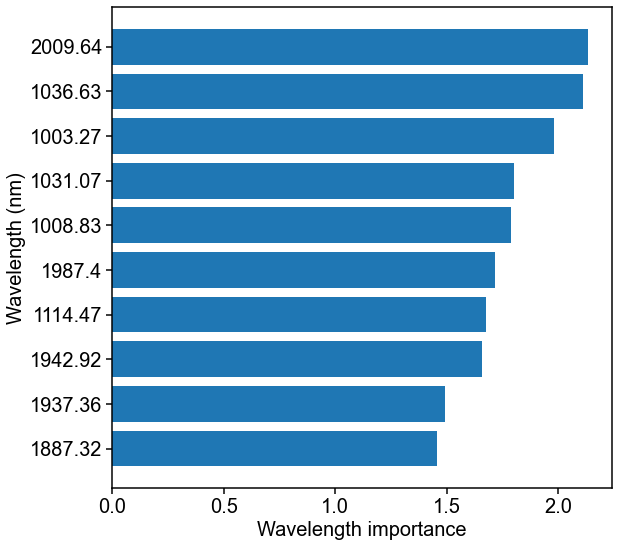

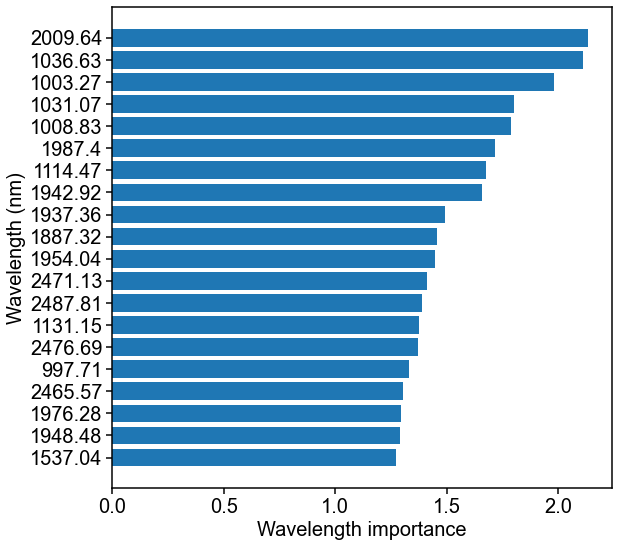

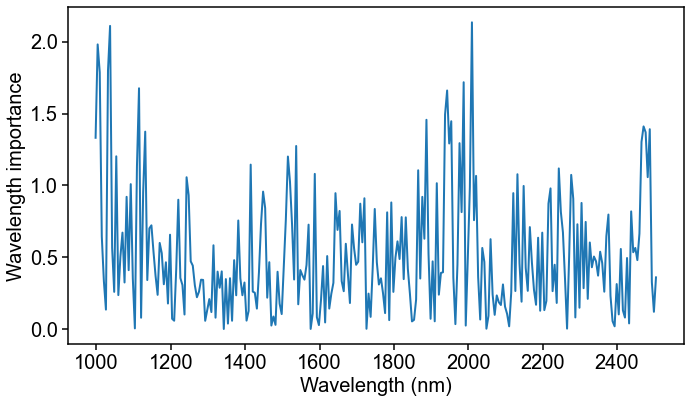


Saved outputs to:
D:\LabData\Menglin Han\Menglin Han coding\Pea project\Pea_TwoSource_Mixed113_KMeans2_ImportantWavelengths


In [5]:
# ============================================================
# Important wavelength analysis for KMeans2 overall classification
#
# Purpose:
#   Identify important wavelengths driving the spectral classification model.
#
# Recommended for:
#   Best KMeans2 model = LogReg
#
# Outputs:
#   1. All wavelength importance table
#   2. Top 10 important wavelengths
#   3. Top 20 important wavelengths
#   4. Important wavelength bar plot
#   5. Full-spectrum importance plot
#
# Run this AFTER the KMeans2 overall classification model has finished.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.base import is_classifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier

# ============================================================
# 0. Settings
# ============================================================

PROJECT_DIR = Path(r"D:\LabData\Menglin Han\Menglin Han coding\Pea project")

OUT_DIR = PROJECT_DIR / "Pea_TwoSource_Mixed113_KMeans2_ImportantWavelengths"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_N = 20

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 20
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["xtick.labelsize"] = 20
plt.rcParams["ytick.labelsize"] = 20
plt.rcParams["legend.fontsize"] = 20

print("Output folder:", OUT_DIR)


# ============================================================
# 1. Select classification model
# ============================================================
# This section tries to find the fitted KMeans2 classification model.
# If your variable names are different, manually assign:
#
# CLASSIFICATION_MODEL = your_fitted_LogReg_model
# CLASSIFICATION_MODEL_NAME = "LogReg"
#
# Important:
# Do not use the protein PLSR final_model here.

CLASSIFICATION_MODEL = None
CLASSIFICATION_MODEL_NAME = None

if "final_classification_model" in globals():
    CLASSIFICATION_MODEL = final_classification_model
    CLASSIFICATION_MODEL_NAME = globals().get("final_classification_model_name", "final_classification_model")

elif "best_classifier_model" in globals():
    CLASSIFICATION_MODEL = best_classifier_model
    CLASSIFICATION_MODEL_NAME = globals().get("best_classifier_model_name", "best_classifier_model")

elif "final_model" in globals() and is_classifier(final_model):
    CLASSIFICATION_MODEL = final_model
    CLASSIFICATION_MODEL_NAME = globals().get("best_model_name", "final_model")

elif "best_model" in globals() and is_classifier(best_model):
    CLASSIFICATION_MODEL = best_model
    CLASSIFICATION_MODEL_NAME = globals().get("best_model_name", "best_model")

else:
    raise RuntimeError(
        "No fitted classification model was found.\n"
        "You may currently be in the protein regression notebook, or final_model is not a classifier.\n\n"
        "Please manually assign:\n"
        "CLASSIFICATION_MODEL = your_fitted_KMeans2_LogReg_model\n"
        "CLASSIFICATION_MODEL_NAME = 'LogReg'\n"
    )

if not is_classifier(CLASSIFICATION_MODEL):
    raise RuntimeError(
        "The selected model is not a classifier. "
        "Make sure you are using the KMeans2 classification model, not the protein regression model."
    )

print("Selected classification model:", CLASSIFICATION_MODEL_NAME)
print(CLASSIFICATION_MODEL)


# ============================================================
# 2. Get wavelength list
# ============================================================

if "wavelengths" not in globals():
    raise RuntimeError(
        "Variable 'wavelengths' was not found.\n"
        "Please make sure your classification notebook has the wavelength list."
    )

wavelength_array = np.asarray(wavelengths, dtype=float)

print("Number of wavelengths:", len(wavelength_array))
print("First 5 wavelengths:", wavelength_array[:5])
print("Last 5 wavelengths:", wavelength_array[-5:])


# ============================================================
# 3. Helper functions
# ============================================================

def get_pipeline_steps(model):
    """
    Return transformer steps and final estimator from a sklearn Pipeline.
    """
    if isinstance(model, Pipeline):
        transformer_steps = model.steps[:-1]
        final_estimator = model.steps[-1][1]
    else:
        transformer_steps = []
        final_estimator = model

    return transformer_steps, final_estimator


def back_project_importance_to_wavelengths(importance, transformer_steps, n_wavelengths):
    """
    Map importance or coefficients back to wavelength space if PCA or feature selection exists.

    For most of your models without PCA:
        importance length = number of wavelengths

    If PCA exists:
        component-level importance is projected back to original wavelengths.
    """

    importance = np.asarray(importance, dtype=float)

    # Case 1: already wavelength-level
    if importance.shape[0] == n_wavelengths:
        return importance

    # Case 2: try to back-project through PCA or feature selection
    imp_current = importance.copy()

    for step_name, step in reversed(transformer_steps):

        # PCA back-projection
        if hasattr(step, "components_"):
            components = step.components_

            if imp_current.shape[0] == components.shape[0]:
                # Convert component importance to wavelength-level importance
                imp_current = np.dot(np.abs(components).T, imp_current)

        # Feature selection back-projection
        elif hasattr(step, "get_support"):
            support = step.get_support()

            if imp_current.shape[0] == np.sum(support):
                full_imp = np.zeros(len(support))
                full_imp[support] = imp_current
                imp_current = full_imp

        # Scaler / SNV / other transformers usually keep feature dimension unchanged
        else:
            pass

    if imp_current.shape[0] != n_wavelengths:
        raise ValueError(
            f"Cannot map importance to wavelengths. "
            f"Importance length = {imp_current.shape[0]}, "
            f"number of wavelengths = {n_wavelengths}."
        )

    return imp_current


def extract_wavelength_importance_from_single_model(model, wavelengths):
    """
    Extract wavelength importance from a fitted classifier.

    Supported:
    - LogisticRegression / linear models with coef_
    - LinearSVC with coef_
    - RandomForest / ExtraTrees with feature_importances_
    - SVC with linear kernel and coef_

    For RBF-SVM:
    - No direct coefficient-based wavelength importance is available.
    """

    n_wavelengths = len(wavelengths)

    transformer_steps, estimator = get_pipeline_steps(model)

    estimator_name = estimator.__class__.__name__

    # --------------------------------------------------------
    # 1. Linear coefficient-based models
    # --------------------------------------------------------
    if hasattr(estimator, "coef_"):

        coef = np.asarray(estimator.coef_, dtype=float)

        # Binary classification: shape usually = (1, n_features)
        # Multiclass classification: shape = (n_classes, n_features)
        if coef.ndim == 1:
            coef_abs = np.abs(coef)
        else:
            coef_abs = np.mean(np.abs(coef), axis=0)

        wavelength_importance = back_project_importance_to_wavelengths(
            importance=coef_abs,
            transformer_steps=transformer_steps,
            n_wavelengths=n_wavelengths
        )

        method = f"{estimator_name}_absolute_coefficient"

    # --------------------------------------------------------
    # 2. Tree-based models
    # --------------------------------------------------------
    elif hasattr(estimator, "feature_importances_"):

        feature_importance = np.asarray(estimator.feature_importances_, dtype=float)

        wavelength_importance = back_project_importance_to_wavelengths(
            importance=feature_importance,
            transformer_steps=transformer_steps,
            n_wavelengths=n_wavelengths
        )

        method = f"{estimator_name}_feature_importance"

    # --------------------------------------------------------
    # 3. Unsupported direct importance
    # --------------------------------------------------------
    else:
        raise RuntimeError(
            f"The final estimator is {estimator_name}, which does not provide direct wavelength importance.\n"
            "If this is SVM_RBF, use permutation importance instead.\n"
            "For your current KMeans2 result, LogReg is recommended for wavelength interpretation."
        )

    # Normalize importance for easier comparison
    wavelength_importance = np.asarray(wavelength_importance, dtype=float)
    wavelength_importance = np.abs(wavelength_importance)

    if np.sum(wavelength_importance) > 0:
        normalized_importance = wavelength_importance / np.sum(wavelength_importance)
    else:
        normalized_importance = wavelength_importance

    importance_df = pd.DataFrame({
        "wavelength": np.asarray(wavelengths, dtype=float),
        "importance_raw": wavelength_importance,
        "importance_normalized": normalized_importance,
        "method": method,
    })

    importance_df = importance_df.sort_values(
        "importance_raw",
        ascending=False
    ).reset_index(drop=True)

    return importance_df, method


def extract_wavelength_importance(model, wavelengths):
    """
    Handle normal model or VotingClassifier.
    """

    transformer_steps, estimator = get_pipeline_steps(model)

    # If final estimator is VotingClassifier, average importances across its estimators
    if isinstance(estimator, VotingClassifier):

        all_imp = []

        for est_name, est in estimator.named_estimators_.items():
            try:
                imp_df, method = extract_wavelength_importance_from_single_model(
                    model=est,
                    wavelengths=wavelengths
                )

                temp = imp_df[["wavelength", "importance_raw"]].copy()
                temp = temp.rename(columns={"importance_raw": est_name})
                all_imp.append(temp)

                print(f"Extracted importance from voting estimator: {est_name}")

            except Exception as e:
                print(f"Skipped voting estimator {est_name}: {e}")

        if len(all_imp) == 0:
            raise RuntimeError("No estimator inside VotingClassifier provided wavelength importance.")

        merged = all_imp[0]

        for temp in all_imp[1:]:
            merged = merged.merge(temp, on="wavelength", how="inner")

        importance_cols = [c for c in merged.columns if c != "wavelength"]

        merged["importance_raw"] = merged[importance_cols].mean(axis=1)

        if merged["importance_raw"].sum() > 0:
            merged["importance_normalized"] = merged["importance_raw"] / merged["importance_raw"].sum()
        else:
            merged["importance_normalized"] = merged["importance_raw"]

        merged["method"] = "VotingClassifier_mean_importance"

        merged = merged.sort_values("importance_raw", ascending=False).reset_index(drop=True)

        return merged, "VotingClassifier_mean_importance"

    else:
        return extract_wavelength_importance_from_single_model(
            model=model,
            wavelengths=wavelengths
        )


def plot_top_wavelengths(importance_df, top_n, output_path):
    plot_df = importance_df.head(top_n).copy()
    plot_df = plot_df.sort_values("importance_raw", ascending=True)
    plot_df["wavelength_label"] = plot_df["wavelength"].round(2).astype(str)

    fig, ax = plt.subplots(figsize=(9, 8))

    ax.barh(
        plot_df["wavelength_label"],
        plot_df["importance_raw"]
    )

    ax.set_xlabel("Wavelength importance")
    ax.set_ylabel("Wavelength (nm)")

    ax.tick_params(direction="out", length=6, width=1.5)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_full_spectrum_importance(importance_df, output_path):
    plot_df = importance_df.sort_values("wavelength").copy()

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(
        plot_df["wavelength"],
        plot_df["importance_raw"],
        linewidth=2
    )

    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Wavelength importance")

    ax.tick_params(direction="out", length=6, width=1.5)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================
# 4. Extract important wavelengths
# ============================================================

importance_df, importance_method = extract_wavelength_importance(
    model=CLASSIFICATION_MODEL,
    wavelengths=wavelength_array
)

print("\nImportance method:", importance_method)

importance_df.to_csv(
    OUT_DIR / "KMeans2_classification_all_wavelength_importance.csv",
    index=False
)

top10_df = importance_df.head(10).copy()
top20_df = importance_df.head(20).copy()

top10_df.to_csv(
    OUT_DIR / "KMeans2_classification_top10_important_wavelengths.csv",
    index=False
)

top20_df.to_csv(
    OUT_DIR / "KMeans2_classification_top20_important_wavelengths.csv",
    index=False
)

print("\nTop 10 important wavelengths:")
display(top10_df)

print("\nTop 20 important wavelengths:")
display(top20_df)


# ============================================================
# 5. Generate figures
# ============================================================

plot_top_wavelengths(
    importance_df=importance_df,
    top_n=10,
    output_path=OUT_DIR / "KMeans2_classification_top10_important_wavelengths.png"
)

plot_top_wavelengths(
    importance_df=importance_df,
    top_n=20,
    output_path=OUT_DIR / "KMeans2_classification_top20_important_wavelengths.png"
)

plot_full_spectrum_importance(
    importance_df=importance_df,
    output_path=OUT_DIR / "KMeans2_classification_full_spectrum_importance.png"
)

print("\nSaved outputs to:")
print(OUT_DIR)